# Core

> Lisette Core

In [ ]:
#| default_exp core_fastllm

In [ ]:
#| hide
from cachy import enable_cachy,disable_cachy,doms

In [ ]:
#| hide
enable_cachy(hdrs=('content-type',))

In [ ]:
#| export
import asyncio, base64, json, litellm, mimetypes, random, string, ast, litellm, warnings
from typing import Optional,Callable
from html import escape
from fastllm.types import *
from fastllm.normalize import *
from fastllm.streaming import *
from fastllm.acomplete import *
from fastllm.cost import *
from toolslm.funccall import mk_ns, call_func, call_func_async, get_schema

from fastcore.utils import *
from fastcore.meta import delegates
from fastcore import imghdr
from fastcore.xml import Safe

from dataclasses import dataclass

In [ ]:
#| hide
from fastcore.test import *
from IPython.display import Markdown, Image, Audio, Video
import httpx

## fastllm

fastllm provides an convenient unified interface for most big LLM providers. Because it's so useful to be able to switch LLM providers with just one argument. We want to make it even easier to by adding some more convenience functions and classes. 

This is very similar to our other wrapper libraries for popular AI providers: [claudette](https://claudette.answer.ai/) (Anthropic), [gaspard](https://github.com/AnswerDotAI/gaspard) (Gemini), [cosette](https://answerdotai.github.io/cosette/) (OpenAI).

```
ToolCall(id='call_3q4lLdRo9pG14Sffcka7aBBa', name='simple_add', arguments={'a': 3, 'b': 5}, server=False, extra={'type': 'function'}),
```

In [ ]:
#| export
@patch
def _repr_markdown_(self: Completion):
    message = self.message
    content = ''
    for p in message.content:
        if txt:=p.text: content += txt
    if self.tool_calls:
        tool_calls = [f"\n\n🔧 {tc.name}({tc.arguments})\n" for tc in self.tool_calls]
        content += "\n".join(tool_calls)
    # for img in getattr(message, 'images', []): content += f"\n\n![generated image]({nested_idx(img, 'image_url', 'url')})" # TODO
    details = [f"model: `{self.model}`", f"finish_reason: `{self.finish_reason}`", f"usage: `{self.usage}`"]
    det_str = '\n- '.join(details)    
    return f"""{content}

<details>

- {det_str}

</details>"""

In [ ]:
#| export
haik45 = "claude-haiku-4-5"
sonn45 = "claude-sonnet-4-5"
sonn = sonn46 = "claude-sonnet-4-6"
opus46 = "claude-opus-4-6"
opus = "claude-opus-4-7"
gpt54 = "gpt-5.4"
gpt54m = "gpt-5.4-mini"
codex54 = "gpt-5.4"
codex55 = "gpt-5.5"

In [ ]:
get_model_meta('claude-opus-4-6')

```python
{ 'cache_creation_input_token_cost': 6.25e-06,
  'cache_creation_input_token_cost_above_1hr': 1e-05,
  'cache_read_input_token_cost': 5e-07,
  'input_cost_per_token': 5e-06,
  'litellm_provider': 'anthropic',
  'max_input_tokens': 1000000,
  'max_output_tokens': 128000,
  'max_tokens': 128000,
  'mode': 'chat',
  'output_cost_per_token': 2.5e-05,
  'provider_specific_entry': {'fast': 6.0, 'us': 1.1},
  'search_context_cost_per_query': { 'search_context_size_high': 0.01,
                                     'search_context_size_low': 0.01,
                                     'search_context_size_medium': 0.01},
  'supports_assistant_prefill': False,
  'supports_computer_use': True,
  'supports_function_calling': True,
  'supports_max_reasoning_effort': True,
  'supports_minimal_reasoning_effort': True,
  'supports_pdf_input': True,
  'supports_prompt_caching': True,
  'supports_reasoning': True,
  'supports_response_schema': True,
  'supports_tool_choice': True,
  'supports_vision': True,
  'tool_use_system_prompt_tokens': 346}
```

In [ ]:
get_model_meta('claude-opus-4-7')

```python
{ 'cache_creation_input_token_cost': 6.25e-06,
  'cache_creation_input_token_cost_above_1hr': 1e-05,
  'cache_read_input_token_cost': 5e-07,
  'input_cost_per_token': 5e-06,
  'litellm_provider': 'anthropic',
  'max_input_tokens': 1000000,
  'max_output_tokens': 128000,
  'max_tokens': 128000,
  'mode': 'chat',
  'output_cost_per_token': 2.5e-05,
  'provider_specific_entry': {'fast': 6.0, 'us': 1.1},
  'search_context_cost_per_query': { 'search_context_size_high': 0.01,
                                     'search_context_size_low': 0.01,
                                     'search_context_size_medium': 0.01},
  'supports_assistant_prefill': False,
  'supports_computer_use': True,
  'supports_function_calling': True,
  'supports_max_reasoning_effort': True,
  'supports_minimal_reasoning_effort': True,
  'supports_pdf_input': True,
  'supports_prompt_caching': True,
  'supports_reasoning': True,
  'supports_response_schema': True,
  'supports_tool_choice': True,
  'supports_vision': True,
  'supports_xhigh_reasoning_effort': True,
  'tool_use_system_prompt_tokens': 346}
```

In [ ]:
ms = ["models/gemini-3-pro-preview", "models/gemini-3-flash-preview", "claude-sonnet-4-6", "gpt-4.1"]
msgs = [Msg(role='user', content=[Part(type=PartType.text, text='Hi there!', data={"cache_control": {"type": "ephemeral"}})])]
for m in ms:
    display(Markdown(f'**{m}:**'))
    display(await acomplete(msgs, m))

<div class="prose">

**models/gemini-3-pro-preview:**

</div>

Hello! How can I help you today?

<details>

- model: `models/gemini-3-pro-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=4, completion_tokens=9, total_tokens=255, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=242, raw={'promptTokenCount': 4, 'candidatesTokenCount': 9, 'totalTokenCount': 255, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 4}], 'thoughtsTokenCount': 242})`

</details>

<div class="prose">

**models/gemini-3-flash-preview:**

</div>

Hello! How can I help you today?

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=4, completion_tokens=9, total_tokens=81, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=68, raw={'promptTokenCount': 4, 'candidatesTokenCount': 9, 'totalTokenCount': 81, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 4}], 'thoughtsTokenCount': 68})`

</details>

<div class="prose">

**claude-sonnet-4-6:**

</div>

Hi there! 👋 How are you doing? Is there something I can help you with today?

<details>

- model: `claude-sonnet-4-6`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=10, completion_tokens=25, total_tokens=35, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 10, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 25, 'service_tier': 'standard', 'inference_geo': 'global'})`

</details>

<div class="prose">

**gpt-4.1:**

</div>

Hello! How can I help you today? 😊

<details>

- model: `gpt-4.1-2025-04-14`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=10, completion_tokens=11, total_tokens=21, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 10, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 11, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 21})`

</details>

In [ ]:
await acomplete(msgs, gpt54)

Hi! How can I help?

<details>

- model: `gpt-5.4-2026-03-05`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=9, completion_tokens=11, total_tokens=20, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 9, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 11, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 20})`

</details>

In [ ]:
await acomplete(msgs, gpt54m)

Hi there! How can I help you today?

<details>

- model: `gpt-5.4-mini-2026-03-17`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=9, completion_tokens=14, total_tokens=23, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 9, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 14, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 23})`

</details>

Generated images are also displayed (not shown here to conserve filesize):

In [ ]:
# completion(model='gemini/gemini-2.5-flash-image', messages=[{'role':'user','content':'Draw a simple sketch of a cat'}])

Custom modifications on model meta

In [ ]:
get_model_info('accounts/fireworks/models/kimi-k2p5', 'fireworks_ai')

```python
{ 'cache_read_input_token_cost': 1e-07,
  'input_cost_per_token': 6e-07,
  'litellm_provider': 'fireworks_ai',
  'max_input_tokens': 262144,
  'max_output_tokens': 262144,
  'max_tokens': 262144,
  'mode': 'chat',
  'output_cost_per_token': 3e-06,
  'source': 'https://fireworks.ai/pricing',
  'supports_function_calling': True,
  'supports_reasoning': True,
  'supports_response_schema': True,
  'supports_tool_choice': True,
  'supports_vision': True}
```

In [ ]:
get_model_info('accounts/fireworks/models/kimi-k2p6', 'fireworks_ai')

```python
{ 'cache_read_input_token_cost': 1e-07,
  'input_cost_per_token': 6e-07,
  'litellm_provider': 'fireworks_ai',
  'max_input_tokens': 262144,
  'max_output_tokens': 262144,
  'max_tokens': 262144,
  'mode': 'chat',
  'output_cost_per_token': 3e-06,
  'source': 'https://fireworks.ai/pricing',
  'supports_function_calling': True,
  'supports_reasoning': True,
  'supports_response_schema': True,
  'supports_tool_choice': True,
  'supports_vision': True}
```

In [ ]:
get_model_info('gpt-5.4', 'openai')

```python
{ 'cache_read_input_token_cost': 2.5e-07,
  'cache_read_input_token_cost_above_272k_tokens': 5e-07,
  'cache_read_input_token_cost_flex': 1.3e-07,
  'cache_read_input_token_cost_priority': 5e-07,
  'input_cost_per_token': 2.5e-06,
  'input_cost_per_token_above_272k_tokens': 5e-06,
  'input_cost_per_token_batches': 1.25e-06,
  'input_cost_per_token_flex': 1.25e-06,
  'input_cost_per_token_priority': 5e-06,
  'litellm_provider': 'openai',
  'max_input_tokens': 1050000,
  'max_output_tokens': 128000,
  'max_tokens': 128000,
  'output_cost_per_token': 1.5e-05,
  'output_cost_per_token_above_272k_tokens': 2.25e-05,
  'output_cost_per_token_batches': 7.5e-06,
  'output_cost_per_token_flex': 7.5e-06,
  'output_cost_per_token_priority': 3e-05,
  'supported_endpoints': ['/v1/chat/completions', '/v1/batch', '/v1/responses'],
  'supported_modalities': ['text', 'image'],
  'supported_output_modalities': ['text'],
  'supports_function_calling': True,
  'supports_minimal_reasoning_effort': True,
  'supports_native_streaming': True,
  'supports_none_reasoning_effort': True,
  'supports_parallel_function_calling': True,
  'supports_pdf_input': True,
  'supports_prompt_caching': True,
  'supports_reasoning': True,
  'supports_response_schema': True,
  'supports_service_tier': True,
  'supports_system_messages': True,
  'supports_tool_choice': True,
  'supports_vision': True,
  'supports_web_search': True,
  'supports_xhigh_reasoning_effort': True}
```

In [ ]:
get_model_info('gpt-5.4', 'codex')

```python
{ 'cache_creation_input_token_cost': 1.0000000000000001e-07,
  'cache_read_input_token_cost': 1.0000000000000001e-07,
  'cache_read_input_token_cost_above_272k_tokens': 5e-07,
  'cache_read_input_token_cost_flex': 1.3e-07,
  'cache_read_input_token_cost_priority': 5e-07,
  'input_cost_per_token': 1.0000000000000001e-07,
  'input_cost_per_token_above_272k_tokens': 5e-06,
  'input_cost_per_token_batches': 1.25e-06,
  'input_cost_per_token_flex': 1.25e-06,
  'input_cost_per_token_priority': 5e-06,
  'litellm_provider': 'openai',
  'max_input_tokens': 1050000,
  'max_output_tokens': 128000,
  'max_tokens': 128000,
  'output_cost_per_token': 5e-07,
  'output_cost_per_token_above_272k_tokens': 2.25e-05,
  'output_cost_per_token_batches': 7.5e-06,
  'output_cost_per_token_flex': 7.5e-06,
  'output_cost_per_token_priority': 3e-05,
  'supported_endpoints': ['/v1/chat/completions', '/v1/batch', '/v1/responses'],
  'supported_modalities': ['text', 'image'],
  'supported_output_modalities': ['text'],
  'supports_function_calling': True,
  'supports_minimal_reasoning_effort': True,
  'supports_native_streaming': True,
  'supports_none_reasoning_effort': True,
  'supports_parallel_function_calling': True,
  'supports_pdf_input': True,
  'supports_prompt_caching': True,
  'supports_reasoning': True,
  'supports_response_schema': True,
  'supports_service_tier': True,
  'supports_system_messages': True,
  'supports_tool_choice': True,
  'supports_vision': True,
  'supports_web_search': True,
  'supports_xhigh_reasoning_effort': True}
```

### Messages formatting

Let's start with making it easier to pass messages into litellm's `completion` function (including images, and pdf files).

In [ ]:
#| export
def _bytes2content(data):
    "Convert bytes to litellm content dict (image, pdf, audio, video)"
    mtype = detect_mime(data)
    if not mtype: raise ValueError(f'Data must be a supported file type, got {data[:10]}')
    encoded = base64.b64encode(data).decode("utf-8")    
    if mtype.startswith('image/'): return Part(type=PartType.input_image, text=f'data:{mtype};base64,{encoded}')
    return Part(type=PartType.input_file, text=f'data:{mtype};base64,{encoded}')


Cache control is added to `Part.data`, it can be added to `tool_use`, `tool_result`, `user`, `asssitant` blocks:

In [ ]:
#| export
def _add_cache_control(msg,          # LiteLLM formatted msg
                       ttl=None):    # Cache TTL: '5m' (default) or '1h'
    "cache `msg` with default time-to-live (ttl) of 5minutes ('5m'), but can be set to '1h'."
    cc = {"type": "ephemeral"} | ({"ttl": ttl} if ttl else {})
    cache_idx = None
    for idx, part in enumerate(msg.content):
        if part.type in (PartType.text, PartType.tool_use): cache_idx = idx
    msg.content[idx].data = merge(msg.content[idx].data or {}, dict(cache_control=cc))
    return msg

def _has_cache(msg):
    "Check if msg has cache_control set"
    return any(part.data and 'cache_control' in part.data for part in msg.content)

def remove_cache_ckpts(msg):
    "remove cache checkpoints and return msg."
    for part in msg.content:
        if part.data: part.data.pop('cache_control', None)
    return msg

def _mk_content(o):
    if isinstance(o, str): return Part(type=PartType.text, text=o.strip())
    elif isinstance(o,bytes): return _bytes2content(o)
    return o

def contents(c):
    "Get Msg object from Completion."
    if not c.message: return ''
    return c.message

def stop_reason(c):
    if not c.finish_reason: return 'unk'
    return c.finish_reason

Test with regular content message:

In [ ]:
msg_content = Msg(role='user', content=[_mk_content('hello')])
_add_cache_control(msg_content)
test_eq(msg_content.content[-1].data.get('cache_control'), {'type': 'ephemeral'})
test_eq(_has_cache(msg_content), True)
remove_cache_ckpts(msg_content)
test_eq(_has_cache(msg_content), False)

Test with assistant message with tool_calls:

In [ ]:
parts = [Part(type=PartType.text, text="I'll calculate both additions for you using the simple_add tool in parallel.", data={'type': 'text', 'text': "I'll calculate both additions for you using the simple_add tool in parallel."}),
        Part(type=PartType.tool_use, text=None, data={'id': 'toolu_01LyH4DdFWEbU9G7cg2XarVf', 'name': 'simple_add', 'arguments': {'a': 3, 'b': 5}, 'server': False, 'caller': {'type': 'direct'}}),
        Part(type=PartType.tool_use, text=None, data={'id': 'toolu_01JrpzizGDyz3BP2Ec2j1Ye1', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 20}, 'server': False, 'caller': {'type': 'direct'}})]
msg_tool = Msg(role='assistant', content=parts, data=None)

In [ ]:
_add_cache_control(msg_tool)
test_eq(msg_tool.content[-1].data.get('cache_control'), {'type': 'ephemeral'})
test_eq(msg_tool.content[0].data.get('cache_control'), None)  # no cache in text
test_eq(_has_cache(msg_tool), True)
remove_cache_ckpts(msg_tool)
test_eq(_has_cache(msg_tool), False)

In [ ]:
#| export
def mk_msg(
    content,      # Content: str, bytes (image), list of mixed content, or dict w 'role' and 'content' fields
    role="user",  # Message role if content isn't already a dict/Message
    cache=False,  # Enable Anthropic caching
    ttl=None      # Cache TTL: '5m' (default) or '1h'
):
    "Create a LiteLLM compatible message."
    if content is None: return None
    if isinstance(content, Msg): return content
    if isinstance(content, Completion): return content.message
    if isinstance(content, list) and len(content) == 1 and isinstance(content[0], str): parts = [Part(PartType.text, content[0])]
    elif isinstance(content, list): parts = [_mk_content(o) for o in content]
    elif isinstance(content, dict): return Msg(role=content['role'], content=[Part(PartType.text, content['content'])])
    else: parts = [Part(PartType.text, content)]
    msg = Msg(role=role, content=parts)
    return _add_cache_control(msg, ttl=ttl) if cache else msg

Now we can use mk_msg to create different types of messages.

Simple text:

In [ ]:
msg = mk_msg("hey")
msg

Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='hey', data=None)], data=None)

Which can be passed to fastllm's `acomplete` function like this:

In [ ]:
model = ms[1] # use 2.5-pro, 3-pro is very slow even to run tests as of making

In [ ]:
res = await acomplete([msg], model)
res

Hello! How can I help you today?

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=2, completion_tokens=9, total_tokens=114, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=103, raw={'promptTokenCount': 2, 'candidatesTokenCount': 9, 'totalTokenCount': 114, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 2}], 'thoughtsTokenCount': 103})`

</details>

We'll add a little shortcut to make examples and testing easier here:

In [ ]:
async def c(msgs, m=model, **kw):
    msgs = [msgs] if isinstance(msgs,Msg) else listify(msgs)
    return await acomplete(msgs, m, **kw)

In [ ]:
await c(msg)

Hello! How can I help you today?

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=2, completion_tokens=9, total_tokens=114, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=103, raw={'promptTokenCount': 2, 'candidatesTokenCount': 9, 'totalTokenCount': 114, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 2}], 'thoughtsTokenCount': 103})`

</details>

Lists w just one string element are flattened for conciseness:

In [ ]:
test_eq(mk_msg("hey"), mk_msg(["hey"]))

Text and images:

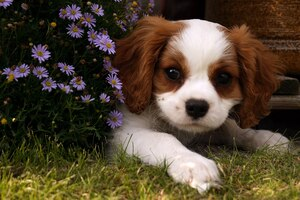

In [ ]:
img_fn = Path('samples/puppy.jpg')
Image(filename=img_fn, width=200)

In [ ]:
msg = mk_msg(['hey what in this image?',img_fn.read_bytes()])
str(msg)[:300]

"Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='hey what in this image?', data=None), Part(type=<PartType.input_image: 'input_image'>, text='data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/4gxUSUNDX1BST0ZJTEUAAQEAAAxEVUNDTQJAAABtbnRyUkdCIFhZWiAH0wAEAAQAAAAAAABhY3NwTVNGVAAAAABDQ"

In [ ]:
await c(msg)

This image features an adorable **Cavalier King Charles Spaniel puppy** lying in a garden.

Here are the details of what’s in the image:

*   **The Puppy:** It has the classic "Blenheim" coloring, which is pearly white with chestnut-brown patches over its ears and eyes. It has large, dark, soulful eyes, a black nose, and long, wavy ears. It is looking directly at the camera while resting on the ground, with one white front paw extended forward.
*   **The Flowers:** To the left of the puppy is a dense cluster of small, light purple or lavender daisy-like flowers (likely asters) with yellow centers.
*   **The Setting:** The puppy is lying on green grass. In the background to the right, there is a dark, textured object that looks like a wooden planter or a piece of garden furniture. The lighting is warm, suggesting a sunny day.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=1087, completion_tokens=196, total_tokens=1962, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=679, raw={'promptTokenCount': 1087, 'candidatesTokenCount': 196, 'totalTokenCount': 1962, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 7}, {'modality': 'IMAGE', 'tokenCount': 1080}], 'thoughtsTokenCount': 679})`

</details>

In [ ]:
await c(msg, 'accounts/fireworks/models/kimi-k2p6', vendor_name='fireworks_ai')

The user wants to know what is in the image. Looking at the image, I can see a small puppy, specifically looks like a Cavalier King Charles Spaniel puppy, with brown and white fur. It's lying down on green grass. There's a bush with small purple flowers (likely asters or similar) next to the puppy on the left side. The puppy has brown ears, a white face with a brown patch over one eye, dark eyes, and a black nose. It appears to be outdoors, possibly in a garden setting.

I should describe the image clearly and accurately. The puppy is the main subject. I should mention the breed if I'm confident (Cavalier King Charles Spaniel), the colors, the setting (grass, flowers), and the pose (lying down, looking at camera).

Let me provide a concise but descriptive answer.This image shows an adorable **Cavalier King Charles Spaniel puppy** lying on green grass. The puppy has the breed's characteristic brown and white coloring, with long, floppy brown ears, dark round eyes, and a black nose. It's resting with its front paws extended and looking directly at the camera.

To the left of the puppy, there's a clump of small **purple flowers** (they look like asters or daisy-like blooms) with yellow centers and green foliage. The setting appears to be an outdoor garden or yard.

<details>

- model: `accounts/fireworks/models/kimi-k2p6`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=107, completion_tokens=283, total_tokens=390, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'prompt_tokens': 107, 'total_tokens': 390, 'completion_tokens': 283, 'prompt_tokens_details': {'cached_tokens': 0}})`

</details>

Let's also demonstrate this for PDFs

In [ ]:
pdf_fn = Path('samples/solveit.pdf')
msg = mk_msg(['Who is the author of this pdf?', pdf_fn.read_bytes()])
await c(msg)

Based on the text in the document, the author is **Jeremy Howard** from **fast.ai**.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=541, completion_tokens=21, total_tokens=704, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=142, raw={'promptTokenCount': 541, 'candidatesTokenCount': 21, 'totalTokenCount': 704, 'promptTokensDetails': [{'modality': 'IMAGE', 'tokenCount': 532}, {'modality': 'TEXT', 'tokenCount': 9}], 'thoughtsTokenCount': 142})`

</details>

Some models like Gemini support audio and video:

In [ ]:
wav_data = httpx.get("https://openaiassets.blob.core.windows.net/$web/API/docs/audio/alloy.wav").content
# Audio(wav_data)  # uncomment to preview

In [ ]:
msg = mk_msg(['What is this audio saying?', wav_data])
await c([msg], ms[1])

The audio says: "The sun rises in the east and sets in the west. This simple fact has been observed by humans for thousands of years."

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=181, completion_tokens=30, total_tokens=297, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=86, raw={'promptTokenCount': 181, 'candidatesTokenCount': 30, 'totalTokenCount': 297, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 7}, {'modality': 'AUDIO', 'tokenCount': 174}], 'thoughtsTokenCount': 86})`

</details>

In [ ]:
vid_data = httpx.get("https://storage.googleapis.com/github-repo/img/gemini/multimodality_usecases_overview/pixel8.mp4").content

In [ ]:
msg = mk_msg(['Concisely, what is happening in this video?', vid_data])
await c([msg], ms[1])

Saeka Shimada, a photographer in Tokyo, demonstrates the "Video Boost" and "Night Sight" capabilities of the Google Pixel 8 Pro. She films the vibrant nightlife and atmospheric alleys of Tokyo, specifically in areas like Sancha and Shibuya, showing how the phone captures high-quality, clear video even in low-light conditions.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=5205, completion_tokens=68, total_tokens=5543, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=270, raw={'promptTokenCount': 5205, 'candidatesTokenCount': 68, 'totalTokenCount': 5543, 'promptTokensDetails': [{'modality': 'VIDEO', 'tokenCount': 5193}, {'modality': 'TEXT', 'tokenCount': 12}], 'thoughtsTokenCount': 270})`

</details>

### Caching

Some providers such as Anthropic require manually opting into caching. Uncomment to run the following tests:

In [ ]:
# def cpr(i): return f'{i} '*1024 + 'This is a caching test. Report back only what number you see repeated above.'

In [ ]:
# #| eval: false
# disable_cachy()

In [ ]:
# msg = mk_msg(cpr(1), cache=True)
# res = await c(msg, ms[2])
# res

Anthropic has a maximum of 4 cache checkpoints, so we remove previous ones as we go:

In [ ]:
# print(res)

In [ ]:
# mk_msg(res)

In [ ]:
# res = await c([remove_cache_ckpts(msg), mk_msg(res), mk_msg(cpr(2), cache=True)], ms[2])
# res

We see that the first message was cached, and this extra message has been written to cache:

In [ ]:
# res.usage.raw

We can add a bunch of large messages in a loop to see how the number of cached tokens used grows.

We do this for 25 times to ensure it still works for more than >20 content blocks, [which is a known anthropic issue](https://docs.claude.com/en/docs/build-with-claude/prompt-caching).

The code below is commented by default, because it's slow. Please uncomment when working on caching.

In [ ]:
# h = []
# msg = mk_msg(cpr(1), cache=True)
# 
# for o in range(2,25):
#     h += [remove_cache_ckpts(msg), mk_msg(res)]
#     msg = mk_msg(cpr(o), cache=True)
#     res = c(h+[msg])
#     detls = res.usage.prompt_tokens_details
#     print(o, detls.cached_tokens, detls.cache_creation_tokens, end='; ')

In [ ]:
# #| hide
# enable_cachy(hdrs=('content-type',))

### Reconstructing formatted outputs

Lisette can call multiple tools in a loop. Further down this notebook, we'll provide convenience functions for formatting such a sequence of toolcalls and responses into one formatted output string.

For now, we'll show an example and show how to transform such a formatted output string back into a valid ~~LiteLLM~~ fastllm history.

```
tool_res_part = Part(type=PartType.tool_result, text='The answer is 42. ' * 200, data={**cc, 'id': 'toolu_test', 'name': 'compute'})
```

In [ ]:
fmt_outp = '''
I'll solve this step-by-step, using parallel calls where possible.

<details class='tool-usage-details'>

```json
{
  "id": "toolu_01KjnQH2Nsz2viQ7XYpLW3Ta",
  "call": { "function": "simple_add", "arguments": { "a": 10, "b": 5 } },
  "result": "15",
  "server": false
}
```

</details>

<details class='tool-usage-details'>

```json
{
  "id": "toolu_01Koi2EZrGZsBbnQ13wuuvzY",
  "call": { "function": "simple_add", "arguments": { "a": 2, "b": 1 } },
  "result": "3",
  "server": false
}
```

</details>

Now I need to multiply 15 * 3 before I can do the final division:

<details class='tool-usage-details'>

```json
{
  "id": "toolu_0141NRaWUjmGtwxZjWkyiq6C",
  "call": { "function": "multiply", "arguments": { "a": 15, "b": 3 } },
  "result": "45",
  "server": false
}
```

</details>

<details class='token-usage-details'><summary>Cache hit: 81.8% | Tokens: total=23,276 input=23,158 (+18,910 cached, 0 new) output=118 (reasoning 23)</summary>

`Usage(prompt_tokens=3, completion_tokens=10, total_tokens=13, raw={'input_tokens': 3, 'cache_creation_input_tokens': 2079, 'cache_read_input_tokens': 2070, 'cache_creation': {'ephemeral_5m_input_tokens': 2079, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 10, 'service_tier': 'standard', 'inference_geo': 'global'})`

</details>
'''

In [ ]:
#| export
tool_dtls_tag = "<details class='tool-usage-details'>"
re_tools = re.compile(fr"^({tool_dtls_tag}\n*(?:<summary>(?P<summary>.*?)</summary>\n*)?\n*```json\n+(.*?)\n+```\n+</details>)",
                      flags=re.DOTALL|re.MULTILINE)
token_dtls_tag = "<details class='token-usage-details'>"
re_token = re.compile(fr"^{re.escape(token_dtls_tag)}<summary>.*?</summary>\n*\n*`.*?`\n*\n*</details>\n?",
                      flags=re.DOTALL|re.MULTILINE)

We can split into chunks of (text,toolstr,json):

In [ ]:
sp = re_tools.split(fmt_outp)
for o in list(chunked(sp, 3, pad=True)): print('- ', o)

-  ["\nI'll solve this step-by-step, using parallel calls where possible.\n\n", '<details class=\'tool-usage-details\'>\n\n```json\n{\n  "id": "toolu_01KjnQH2Nsz2viQ7XYpLW3Ta",\n  "call": { "function": "simple_add", "arguments": { "a": 10, "b": 5 } },\n  "result": "15",\n  "server": false\n}\n```\n\n</details>', None]
-  ['{\n  "id": "toolu_01KjnQH2Nsz2viQ7XYpLW3Ta",\n  "call": { "function": "simple_add", "arguments": { "a": 10, "b": 5 } },\n  "result": "15",\n  "server": false\n}', '\n\n', '<details class=\'tool-usage-details\'>\n\n```json\n{\n  "id": "toolu_01Koi2EZrGZsBbnQ13wuuvzY",\n  "call": { "function": "simple_add", "arguments": { "a": 2, "b": 1 } },\n  "result": "3",\n  "server": false\n}\n```\n\n</details>']
-  [None, '{\n  "id": "toolu_01Koi2EZrGZsBbnQ13wuuvzY",\n  "call": { "function": "simple_add", "arguments": { "a": 2, "b": 1 } },\n  "result": "3",\n  "server": false\n}', '\n\nNow I need to multiply 15 * 3 before I can do the final division:\n\n']
-  ['<details class=\'t

```py
tool_use_msg = Msg(role='assistant', content=[Part(type=PartType.tool_use, data={'id': 'toolu_test', 'name': 'compute', 'arguments': {}, 'server': False})])
tool_res_msg = Msg(role='tool', content=[Part(type=PartType.tool_result, text='The answer is 42. ' * 200, data={**cc, 'id': 'toolu_test', 'name': 'compute'})])
```

In [ ]:
#| export
def _extract_tool_parts(text:str):
    "Extract (tool_use_part, tool_result_part) from <details> json block"
    try: d = json.loads(text.strip())
    except: return None
    call = d['call']
    # Skip server tool calls in deserialization (round trip issues with Gemini/Anthropic)
    if d.get('server'): return None
    tu = Part(type=PartType.tool_use, text=None, data={'id': d['id'], 'name': call['function'], 'arguments': call['arguments']})
    tr = Part(type=PartType.tool_result, text=str(d['result']), data={'id': d['id'], 'name': call['function']})
    return tu, tr

def split_tools(s):
    "Split formatted output into (text, summary, tooljson) chunks"
    return [(txt,summ,tj) for txt,_,summ,tj in chunked(re_tools.split(s.strip()), 4, pad=True)]

def fmt2hist(outp:str)->list[Msg]:
    "Transform a formatted output string into fastllm canonical Msgs"
    if token_dtls_tag in outp: outp = re_token.sub('', outp)
    if tool_dtls_tag not in outp: return [Msg(role='assistant', content=[Part(type=PartType.text, text=outp.strip())])]
    hist, asst_parts, tool_parts = [], [], []
    def flush():
        if tool_parts:
            hist.append(Msg(role='assistant', content=asst_parts.copy()))
            hist.append(Msg(role='tool',      content=tool_parts.copy()))
            asst_parts.clear(); tool_parts.clear()
    for txt,_,tj in split_tools(outp):
        if txt and txt.strip():
            if tool_parts: flush()   # text after tool results => new assistant turn
            asst_parts.append(Part(type=PartType.text, text=txt.strip()))
        if tj and (tp := _extract_tool_parts(tj)):
            asst_parts.append(tp[0])
            tool_parts.append(tp[1])
    flush()
    if asst_parts: hist.append(Msg(role='assistant', content=asst_parts))
    # TODO: Is this needed?
    # if hist and hist[-1].role == 'tool':
    #     hist.append(Msg(role='assistant', content=[Part(type=PartType.text, text='.')]))
    return hist

See how we can turn that one formatted output string back into a list of Msg:

In [ ]:
from pprint import pprint

In [ ]:
h = fmt2hist(fmt_outp)
pprint(h)

[Msg(role='assistant',
     content=[Part(type=<PartType.text: 'text'>,
                   text="I'll solve this step-by-step, using parallel calls "
                        'where possible.',
                   data=None),
              Part(type=<PartType.tool_use: 'tool_use'>,
                   text=None,
                   data={'arguments': {'a': 10, 'b': 5},
                         'id': 'toolu_01KjnQH2Nsz2viQ7XYpLW3Ta',
                         'name': 'simple_add'}),
              Part(type=<PartType.tool_use: 'tool_use'>,
                   text=None,
                   data={'arguments': {'a': 2, 'b': 1},
                         'id': 'toolu_01Koi2EZrGZsBbnQ13wuuvzY',
                         'name': 'simple_add'})],
     data=None),
 Msg(role='tool',
     content=[Part(type=<PartType.tool_result: 'tool_result'>,
                   text='15',
                   data={'id': 'toolu_01KjnQH2Nsz2viQ7XYpLW3Ta',
                         'name': 'simple_add'}),
              Part

In [ ]:
sch = {'type': 'function',
 'function': {'name': 'simple_div',
  'description': 'divide numbers',
  'parameters': {'type': 'object',
   'properties': {'a': {'description': '', 'type': 'integer'},
    'b': {'description': '', 'type': 'integer'}},
   'required': ['a', 'b']}}}

In [ ]:
user_q = Msg(role='user', content=[Part(type=PartType.text, text='Compute (10+5) * (2+1), then divide by 5.')])
for m in ms:
    display(Markdown(f'**{m}:**'))
    display(await c([user_q] + h, m, tools=[sch]))

<div class="prose">

**models/gemini-3-pro-preview:**

</div>

Finally, I'll divide 45 by 5:

🔧 simple_div({'a': 45, 'b': 5})


<details>

- model: `models/gemini-3-pro-preview`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=201, completion_tokens=32, total_tokens=233, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'promptTokenCount': 201, 'candidatesTokenCount': 32, 'totalTokenCount': 233, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 201}]})`

</details>

<div class="prose">

**models/gemini-3-flash-preview:**

</div>

Now I'll divide 45 by 5:

🔧 simple_div({'b': 5, 'a': 45})


<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=201, completion_tokens=31, total_tokens=232, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'promptTokenCount': 201, 'candidatesTokenCount': 31, 'totalTokenCount': 232, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 201}]})`

</details>

<div class="prose">

**claude-sonnet-4-6:**

</div>

Now I can divide 45 by 5:

🔧 simple_div({'a': 45, 'b': 5})


<details>

- model: `claude-sonnet-4-6`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=901, completion_tokens=82, total_tokens=983, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 901, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 82, 'service_tier': 'standard', 'inference_geo': 'global'})`

</details>

<div class="prose">

**gpt-4.1:**

</div>



🔧 simple_div({'a': 45, 'b': 5})


<details>

- model: `gpt-4.1-2025-04-14`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=177, completion_tokens=19, total_tokens=196, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 177, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 19, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 196})`

</details>

### `mk_msgs`

We will skip tool use blocks and tool results during caching

In [ ]:
#| export
def _apply_cache_idxs(msgs, cache_idxs=[-1], ttl=None):
    "Add cache control to `cache_idxs` after filtering tool-role msgs"
    ms = [j for j,m in enumerate(msgs) if m.role != 'tool']
    for i in cache_idxs:
        try: idx = ms[i]
        except IndexError: continue
        _add_cache_control(msgs[idx], ttl)

Now lets make it easy to provide entire conversations:

In [ ]:
#| export
def mk_msgs(
    msgs,                   # List of messages (each: str, bytes, list, Msg, or Completion)
    cache=False,            # Enable Anthropic caching
    cache_idxs=[-1],        # Cache breakpoint idxs
    ttl=None,               # Cache TTL: '5m' (default) or '1h'
):
    "Create a list of fastllm canonical Msgs."
    if not msgs: return []
    if not isinstance(msgs, list): msgs = [msgs]
    msgs = L(msgs).map(lambda m: fmt2hist(m) if isinstance(m,str) and tool_dtls_tag in m else [m]).concat()
    res, role = [], 'user'
    for m in msgs:
        res.append(msg := remove_cache_ckpts(mk_msg(m, role=role)))
        role = 'assistant' if msg.role in ('user','tool') else 'user'
    if cache: _apply_cache_idxs(res, cache_idxs, ttl)
    return res

With `mk_msgs` you can easily provide a whole conversation:

In [ ]:
msgs = mk_msgs(['Hey!',"Hi there!","How are you?","I'm doing fine and you?"])
msgs

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Hey!', data=None)], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Hi there!', data=None)], data=None),
 Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='How are you?', data=None)], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text="I'm doing fine and you?", data=None)], data=None)]

By defualt the last message will be cached when `cache=True`:

In [ ]:
msgs = mk_msgs(['Hey!',"Hi there!","How are you?","I'm doing fine and you?"], cache=True)
msgs

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Hey!', data=None)], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Hi there!', data=None)], data=None),
 Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='How are you?', data=None)], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text="I'm doing fine and you?", data={'cache_control': {'type': 'ephemeral'}})], data=None)]

In [ ]:
test_eq('cache_control' in msgs[-1].content[-1].data, True)

Alternatively, users can provide custom `cache_idxs`. Tool call blocks and results are skipped during caching:

In [ ]:
msgs = mk_msgs(['Hello!','Hi! How can I help you?','Call some functions!',fmt_outp], cache=True, cache_idxs=[0,-2,-1])
msgs

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Hello!', data={'cache_control': {'type': 'ephemeral'}})], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Hi! How can I help you?', data=None)], data=None),
 Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Call some functions!', data=None)], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text="I'll solve this step-by-step, using parallel calls where possible.", data=None), Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': 'toolu_01KjnQH2Nsz2viQ7XYpLW3Ta', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 5}}), Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': 'toolu_01Koi2EZrGZsBbnQ13wuuvzY', 'name': 'simple_add', 'arguments': {'a': 2, 'b': 1}, 'cache_control': {'type': 'ephemeral'}})], data=None),
 Msg(role='tool', content=[Part(type=<PartType.tool_result: 'tool_result'>, text='15', data={'id': 'tool

In [ ]:
msgs[-2]

Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Now I need to multiply 15 * 3 before I can do the final division:', data=None), Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': 'toolu_0141NRaWUjmGtwxZjWkyiq6C', 'name': 'multiply', 'arguments': {'a': 15, 'b': 3}, 'cache_control': {'type': 'ephemeral'}})], data=None)

In [ ]:
msgs = mk_msgs(['Hello!','Hi! How can I help you?','Call some functions!',fmt_outp], cache=True, cache_idxs=[0,-3,-2])
msgs

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Hello!', data={'cache_control': {'type': 'ephemeral'}})], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Hi! How can I help you?', data=None)], data=None),
 Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Call some functions!', data={'cache_control': {'type': 'ephemeral'}})], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text="I'll solve this step-by-step, using parallel calls where possible.", data=None), Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': 'toolu_01KjnQH2Nsz2viQ7XYpLW3Ta', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 5}}), Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': 'toolu_01Koi2EZrGZsBbnQ13wuuvzY', 'name': 'simple_add', 'arguments': {'a': 2, 'b': 1}, 'cache_control': {'type': 'ephemeral'}})], data=None),
 Msg(role='tool', content=[Part(type=<PartType.tool_result: 'tool_re

In [ ]:
test_eq(msgs[-3].role == 'tool', True)
test_eq(_has_cache(msgs[-3]), False)

In [ ]:
test_eq(msgs[-5].role == 'tool', False)
test_eq(_has_cache(msgs[-5]), True)

In [ ]:
test_eq('cache_control' in msgs[0].content[0].data, True)

Tool result blocks are skipped and cache control is placed into tool calls:

In [ ]:
tc_part = msgs[3].content[-1]
test_eq(tc_part.type == PartType.tool_use, True)
test_eq('cache_control' in tc_part.data, True)

In [ ]:
L(msgs).map(remove_cache_ckpts)
test_eq(any(L(msgs).map(_has_cache)), False)

Who's speaking at when is automatically inferred.
Even when there are multiple tools being called in parallel (which LiteLLM supports!).

In [ ]:
msgs = mk_msgs(['Tell me the weather in Paris and Rome',
                'Assistant calls weather tool two times',
                {'role':'tool','content':'Weather in Paris is ...'},
                {'role':'tool','content':'Weather in Rome is ...'},
                'Assistant returns weather',
                'Thanks!'])
msgs

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Tell me the weather in Paris and Rome', data=None)], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Assistant calls weather tool two times', data=None)], data=None),
 Msg(role='tool', content=[Part(type=<PartType.text: 'text'>, text='Weather in Paris is ...', data=None)], data=None),
 Msg(role='tool', content=[Part(type=<PartType.text: 'text'>, text='Weather in Rome is ...', data=None)], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Assistant returns weather', data=None)], data=None),
 Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Thanks!', data=None)], data=None)]

In [ ]:
#| hide
test_eq([m.role for m in msgs],['user','assistant','tool','tool','assistant','user'])

For ease of use, if `msgs` is not already in a `list`, it will automatically be wrapped inside one. This way you can pass a single prompt into `mk_msgs` and get back a ~~LiteLLM~~ fastllm compatible msg history.

In [ ]:
msgs = mk_msgs("Hey")
msgs

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Hey', data=None)], data=None)]

In [ ]:
#| hide
msgs = mk_msgs({'role':'tool','content':'fake tool result'})
msgs

[Msg(role='tool', content=[Part(type=<PartType.text: 'text'>, text='fake tool result', data=None)], data=None)]

In [ ]:
msgs = mk_msgs(['Hey!',"Hi there!","How are you?","I'm fine, you?"])
msgs

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Hey!', data=None)], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Hi there!', data=None)], data=None),
 Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='How are you?', data=None)], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text="I'm fine, you?", data=None)], data=None)]

However, beware that if you use `mk_msgs` for a single message, consisting of multiple parts.
Then you should be explicit, and make sure to wrap those multiple messages in two lists:

1. One list to show that they belong together in one message (the inner list).
2. Another, because mk_msgs expects a list of multiple messages (the outer list).

This is common when working with images for example:

In [ ]:
msgs = mk_msgs([['Whats in this img?',img_fn.read_bytes()]])
test_eq(len(msgs), 1)
test_eq(len(msgs[0].content), 2) # A single msg 1 text and 1 image part

In [ ]:
str(msgs)[:300]

"[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Whats in this img?', data=None), Part(type=<PartType.input_image: 'input_image'>, text='data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/4gxUSUNDX1BST0ZJTEUAAQEAAAxEVUNDTQJAAABtbnRyUkdCIFhZWiAH0wAEAAQAAAAAAABhY3NwTVNGVAAAAABDQU5PW"

Anthropic models use the new adaptive thinking by default. Canonical `reasoning_effort` values include minimal, low, medium, high, xhigh (Anthropic), max (Anthropic). Gemini reasoning effort is handled as same as litellm using thinkingLevel for newer models and thinkingBudget otherwise. OpenAI Responses and Chat APIs levels are passthrough:

In [ ]:
res = await c([mk_msg("What's 213127*451233? Think step by step. ")], opus, reasoning_effort='medium'); res

# Computing 213,127 × 451,233

**Step 1: Split 451,233 into 450,000 + 1,233**

**Step 2: Compute 213,127 × 450,000**
- 213,127 × 45 = 213,127 × 40 + 213,127 × 5
- = 8,525,080 + 1,065,635 = 9,590,715
- Multiply by 10,000: **95,907,150,000**

**Step 3: Compute 213,127 × 1,233**
- 213,127 × 1,000 = 213,127,000
- 213,127 × 200 = 42,625,400
- 213,127 × 33 = 213,127 × 30 + 213,127 × 3 = 6,393,810 + 639,381 = 7,033,191
- Sum: 213,127,000 + 42,625,400 + 7,033,191 = **262,785,591**

**Step 4: Add the two parts**
- 95,907,150,000 + 262,785,591 = **96,169,935,591**

## Answer: **96,169,935,591**

<details>

- model: `claude-opus-4-7`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=27, completion_tokens=699, total_tokens=726, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 27, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 699, 'service_tier': 'standard', 'inference_geo': 'global'})`

</details>

Thinking and text parts ares stored separately:

In [ ]:
L(res.message.content).attrgot('type')

[<PartType.thinking: 'thinking'>, <PartType.text: 'text'>]

## Streaming

fastllm supports streaming, and returns the same `Completion` object as non-streaming at the end

fastllm is async first

In [ ]:
#| export
def cite_footnote(citations):
    'Build citation footnotes for a single Delta'
    links = []
    for c in citations:
        if 'title' not in c: return ''
        title = c['title'].replace('"', '\\"')
        links.append(f'[*]({c["url"]} "{title}")')
    return ' '.join(links)

In [ ]:
#| export
def postproc(chunk):
    if isinstance(chunk, dict) and 'citations' in chunk: return dict(citations=cite_footnote(chunk['citations']))
    return chunk

In [ ]:
@asave_iter
async def stream_with_complete(self, gen, postproc=postproc):
    async for chunk in gen:
        if isinstance(chunk, Completion): self.value = chunk
        else: yield postproc(chunk)

fastllm's `_acollect_stream` yields `{'text':...}`, `{'thinking':...}` and `{'citations':...}` dicts, and builds up the final `Completion` which is returned at the end. Only Anthropic streams citations together with text, other providers such as Gemini returns it at the end. OpenAI Responses already include citation links in it's text response so doesn't require a special enrichment process.

In [ ]:
async def print_stream(r):
    async for o in r:
        if isinstance(o, dict): 
            if cts:=(o.get('thinking') or o.get('text') or o.get('citations')): print(cts, end='')

In [ ]:
r = await c(mk_msgs("Hi!"),stream=True)
r2 = stream_with_complete(r)
await print_stream(r2)

Hello! How can I help you today?

In [ ]:
r2.value

Hello! How can I help you today?

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=3, completion_tokens=9, total_tokens=74, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=62, raw={'promptTokenCount': 3, 'candidatesTokenCount': 9, 'totalTokenCount': 74, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 3}], 'thoughtsTokenCount': 62})`

</details>

In [ ]:
r = await c(mk_msgs("What's the weather in Istanbul"), m=ms[-2], stream=True, web_search_options={})
r2 = stream_with_complete(r, postproc)
await print_stream(r2)

Here's the current weather in **Istanbul, Turkey** based on the latest data:

🌙 **Tonight (Thu, Apr 23):** Clear skies, with a temperature of **48°F (9°C)**. The RealFeel® is also 48°F.

💨 **Wind:** SSW at **4 mph**, with gusts up to **6 mph**.

📉 **Tonight's Low:** 46°F (8°C)

☀️ **Tomorrow:** Mostly sunny with a **High of 65°F (18°C)**.

⚠️ **Air Quality:** Unhealthy — take precautions if you're sensitive to air pollution.

Overall, it's a clear and cool night in Istanbul, with a pleasant and warmer day expected tomorrow!

Citations may not appear if web search is run with `code_execution`:

In [ ]:
r2.value.tool_calls

[ToolCall(id='srvtoolu_011tz9YB7h598eLkv25Nvkch', name='code_execution', arguments={'code': '\nresult = await web_search({"query": "current weather in Istanbul today"})\nimport json\ndata = json.loads(result)\nfor r in data[:3]:\n    print(r[\'title\'])\n    print(r[\'content\'][:500])\n    print("---")\n'}, server=True, extra={}),
 ToolCall(id='srvtoolu_01SJRpfFcNtPSdCben924u5Q', name='web_search', arguments={'query': 'current weather in Istanbul today'}, server=True, extra={'caller': {'type': 'code_execution_20260120', 'tool_id': 'srvtoolu_011tz9YB7h598eLkv25Nvkch'}}),
 ToolCall(id='srvtoolu_014couFj6uvfe88TqGxooBu1', name='code_execution', arguments={'code': '\nfor r in data[:3]:\n    print(r[\'title\'])\n    print(r[\'content\'][:1500])\n    print("---")\n'}, server=True, extra={})]

We can try with an older version which will have citations:

In [ ]:
r = await c(mk_msgs("What's the weather in Istanbul"), m=ms[-2], stream=True, web_search_options={'type': 'web_search_20250305'})
r2 = stream_with_complete(r, postproc)
await print_stream(r2)

Here's the current weather in **Istanbul, Turkey** 🌤️:

- **Condition:** [*](https://www.accuweather.com/en/tr/istanbul/318251/current-weather/318251 "Istanbul, Istanbul, Türkiye Current Weather | AccuWeather")Istanbul is currently mostly clear.
- **Temperature:** [*](https://www.accuweather.com/en/tr/istanbul/318251/current-weather/318251 "Istanbul, Istanbul, Türkiye Current Weather | AccuWeather")The temperature is **46°F (8°C)**, with a RealFeel® of **45°F**, feeling chilly, based on 74% humidity, 21% cloud cover, and winds of 5 mph.
- **Wind:** [*](https://www.accuweather.com/en/tr/istanbul/318251/current-weather/318251 "Istanbul, Istanbul, Türkiye Current Weather | AccuWeather")Winds are coming from the SSW at **5 mph**, with gusts up to **5 mph**.
- **Humidity:** [*](https://www.accuweather.com/en/tr/istanbul/318251/current-weather/318251 "Istanbul, Istanbul, Türkiye Current Weather | AccuWeather")Humidity is at **74%**, with a dew point of 39°F.
- **Visibility:** [*](https://www

In [ ]:
r2.value.tool_calls

[ToolCall(id='srvtoolu_01MmxFH2gXVde2okXdYskSUT', name='web_search', arguments={'query': 'weather in Istanbul today'}, server=True, extra={})]

## Tools

In [ ]:
#| export
def lite_mk_func(f):
    if isinstance(f, dict): return f
    return {'type':'function', 'function':get_schema(f, pname='parameters')}

In [ ]:
def simple_add(
    a: int,   # first operand
    b: int=0  # second operand
) -> int:
    "Add two numbers together"
    return a + b

In [ ]:
toolsc = lite_mk_func(simple_add)

In [ ]:
tmsg = mk_msg("What is 5478954793+547982745? How about 5479749754+9875438979? Always use tools for calculations, and describe what you'll do before using a tool. Where multiple tool calls are required, do them in a single response where possible. ")
r = await c(tmsg, tools=[toolsc])

In [ ]:
display(r)

I will use the `simple_add` tool twice to calculate the sums of the two pairs of numbers you provided.



🔧 simple_add({'a': 5478954793, 'b': 547982745})



🔧 simple_add({'a': 5479749754, 'b': 9875438979})


<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=160, completion_tokens=96, total_tokens=426, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=170, raw={'promptTokenCount': 160, 'candidatesTokenCount': 96, 'totalTokenCount': 426, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 160}], 'thoughtsTokenCount': 170})`

</details>

`Completion.tool_calls` is available as a convenience for user to access tool calls, and create results for them using `mk_tool_res_msg` from fastllm:

In [ ]:
r.tool_calls

[ToolCall(id='h6lg4no4', name='simple_add', arguments={'a': 5478954793, 'b': 547982745}, server=False, extra={'thoughtSignature': 'Er0ECroEAQw51sePind+LwoBffu1hThYBpVOlJN6sHm0fk9Yx7WY9ciZBgOLSPYSPA13cKYlfU7kBX16WXC7rVa12T7KXtHMUFqiU/I+8u9mNtZgrTaK7gdsbYUjxG5C10VAtywfZ7Pe6wR4VRmMIESk0wv67wt75MVenynbKjqw4yITzYUmGbI8/MiwwS4Dka3LDWM+sq4Ew0BmkmNd0XsA9VGoN0vdcAnPpRRr5CmYkoXDLGG+dSJZa/QbXF0ij3dhQmnRvTC3hxWG7znRqek5z7tmin2xAexeh/aEFNwBBmdt6+PNi17flFSTebQyjgSeH1A3O0rO4aj5+KKaXZvzmojzCm+Tq3WiT54ETR2Ejbs9JKTCwuI6ZGS43Rukw2BIXFT1uhFP64UpUtr8FdUp2mJ9IRA5K51X/miAjMWa42EYwBegeKVkw2JNb+w2JX3g6Rx8dwvIeO+nqWAlUn0KzGZFJqk2QXUtjSBMN8IJwWK8414CztOa4aGUNuaQlmI/D1FJ5l7i/N/frUNon3EJK7NCPRUEKaU38EQBaqg0Mn4Ut62lX9wrT4N/peg/f0jmBZm9fzphY24RS2amZm9tpK339y4U2bsgt9A9QSbiK0UrQivffsHYdMTaHcCRaxNX/FIUaajOBvk/xeoLzYzZ17iINsJizKiewbolCjif7pnkjiVgN9p/ElROhNRqd88+5Ak5qn0V0a8RDd7okkRrltP6elORACUR/yd04NYmHYNARZPQpW/tY8DWgC1Z'}),
 ToolCall(id='kwfi3045', name='simple_add', arguments={'a': 5479749754, 'b': 9875438979}, server

`Completion.message` can be directly appended to `hist` to continue the chat:

In [ ]:
r.message.content

[Part(type=<PartType.text: 'text'>, text='I will use the `simple_add` tool twice to calculate the sums of the two pairs of numbers you provided.\n\n', data={'text': 'I will use the `simple_add` tool twice to calculate the sums of the two pairs of numbers you provided.\n\n'}),
 Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'thoughtSignature': 'Er0ECroEAQw51sePind+LwoBffu1hThYBpVOlJN6sHm0fk9Yx7WY9ciZBgOLSPYSPA13cKYlfU7kBX16WXC7rVa12T7KXtHMUFqiU/I+8u9mNtZgrTaK7gdsbYUjxG5C10VAtywfZ7Pe6wR4VRmMIESk0wv67wt75MVenynbKjqw4yITzYUmGbI8/MiwwS4Dka3LDWM+sq4Ew0BmkmNd0XsA9VGoN0vdcAnPpRRr5CmYkoXDLGG+dSJZa/QbXF0ij3dhQmnRvTC3hxWG7znRqek5z7tmin2xAexeh/aEFNwBBmdt6+PNi17flFSTebQyjgSeH1A3O0rO4aj5+KKaXZvzmojzCm+Tq3WiT54ETR2Ejbs9JKTCwuI6ZGS43Rukw2BIXFT1uhFP64UpUtr8FdUp2mJ9IRA5K51X/miAjMWa42EYwBegeKVkw2JNb+w2JX3g6Rx8dwvIeO+nqWAlUn0KzGZFJqk2QXUtjSBMN8IJwWK8414CztOa4aGUNuaQlmI/D1FJ5l7i/N/frUNon3EJK7NCPRUEKaU38EQBaqg0Mn4Ut62lX9wrT4N/peg/f0jmBZm9fzphY24RS2amZm9tpK339y4U2bsgt9A9QSbiK0UrQivffsHYdMTaHcCRa

A tool response can be a string or a list of tool blocks (e.g., an image url block). To allow users to specify if a response should not be immediately stringified, we provide the ToolResponse datatype users can wrap their return statement in.

In [ ]:
#| export
@dataclass
class ToolResponse:
    content: list[str,str]

In [ ]:
tool_calls = [ToolCall(id='123', name='simple_add', arguments={'a': 3, 'b': 5}, server=False, extra={'type': 'function'}), 
              ToolCall(id='456', name='simple_add', arguments={'a': 10, 'b': 20}, server=False, extra={'type': 'function'})]

In [ ]:
#| export
def _mk_tool_result(res):
    "Unwrap `ToolResponse`, and format tool result message"
    if isinstance(res, ToolResponse): return res.content
    if isinstance(res, str): content = res
    else: content = str(res)
    return content

In [ ]:
_mk_tool_result('8'), _mk_tool_result('30')

('8', '30')

In [ ]:
mk_tool_res_msg(tool_calls, (_mk_tool_result('8'), _mk_tool_result('30')))

Msg(role='tool', content=[Part(type=<PartType.tool_result: 'tool_result'>, text='8', data={'id': '123', 'name': 'simple_add', 'arguments': {'a': 3, 'b': 5}, 'server': False}), Part(type=<PartType.tool_result: 'tool_result'>, text='30', data={'id': '456', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 20}, 'server': False})], data=None)

Ensure `ToolResponse` content (e.g. `PartType.input_image`, `PartType.input_file` blocks) is passed through as a list, not stringified:

In [ ]:
img_content = [Part(type=PartType.input_image, text='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAAQAAAAECAIAAAAmkwkpAAAAEElEQVR4nGP4z8AARwzEcQCukw/x0F8jngAAAABJRU5ErkJggg==')]
res = _mk_tool_result(ToolResponse(img_content))
test_eq(res, img_content)  # ToolResponse should pass through

In [ ]:
tc = ToolCall('_test', 'test_img', {}, server=False)
tc_part = Part(type=PartType.tool_use, text=None, data={'id': '_test', 'name': 'test_img', 'arguments': {}, 'server':False})
msg0 = mk_msg("What's in this image?")
msg1 = Msg(role='assistant', content=[tc_part])
msg2 = mk_tool_res_msg([tc], [res])

In [ ]:
[msg0,msg1,msg2]

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text="What's in this image?", data=None)], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': '_test', 'name': 'test_img', 'arguments': {}, 'server': False})], data=None),
 Msg(role='tool', content=[Part(type=<PartType.tool_result: 'tool_result'>, text=[Part(type=<PartType.input_image: 'input_image'>, text='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAAQAAAAECAIAAAAmkwkpAAAAEElEQVR4nGP4z8AARwzEcQCukw/x0F8jngAAAABJRU5ErkJggg==', data=None)], data={'id': '_test', 'name': 'test_img', 'arguments': {}, 'server': False})], data=None)]

In [ ]:
r = await c([msg0,msg1,msg2]); r

This image is a solid, vibrant red color. It is a single, uniform shade of red throughout the entire frame.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=1120, completion_tokens=24, total_tokens=1175, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=31, raw={'promptTokenCount': 1120, 'candidatesTokenCount': 24, 'totalTokenCount': 1175, 'promptTokensDetails': [{'modality': 'IMAGE', 'tokenCount': 1089}, {'modality': 'TEXT', 'tokenCount': 31}], 'thoughtsTokenCount': 31})`

</details>

In [ ]:
#| export
def _call_func(tc:ToolCall, tool_schemas, ns, callf):
    "Call tool function synchronously and return formatted result"
    fn, valid = tc.name, {nested_idx(o,'function','name') for o in tool_schemas or []}
    if fn not in valid: return f"Tool not defined in tool_schemas: {fn}"
    else: return callf(fn, tc.arguments, ns=ns, raise_on_err=False)

In [ ]:
#| export
def _lite_call_func(tc, tool_schemas, ns):
    "Call tool function synchronously and return formatted result"
    res = _call_func(tc, tool_schemas, ns, call_func)
    return _mk_tool_result(res)

In [ ]:
tcres = [_lite_call_func(o, [toolsc], ns=globals()) for o in tool_calls]
tcres

['8', '30']

In [ ]:
mk_tool_res_msg(tool_calls, tcres)

Msg(role='tool', content=[Part(type=<PartType.tool_result: 'tool_result'>, text='8', data={'id': '123', 'name': 'simple_add', 'arguments': {'a': 3, 'b': 5}, 'server': False}), Part(type=<PartType.tool_result: 'tool_result'>, text='30', data={'id': '456', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 20}, 'server': False})], data=None)

Test tool calls that were not in tool_schemas are caught:

In [ ]:
fake_tc = ToolCall(id='_', name='hallucinated_tool', arguments={}, server=False)
test_eq(_lite_call_func(fake_tc, ns=globals(), tool_schemas=[toolsc]),"Tool not defined in tool_schemas: hallucinated_tool")
test_fail(_lite_call_func(fake_tc, ns=globals(), tool_schemas=None),"Tool not defined in tool_schemas: hallucinated_tool")

Test tool calls that were not in tool_choice are caught:

## Structured Outputs

In [ ]:
#| export
@delegates(acomplete)
async def structured(
    m:str,          # LiteLLM model string
    msgs:list,      # List of messages 
    tool:Callable,  # Tool to be used for creating the structured output (class, dataclass or Pydantic, function, etc)
    sp:str|Part='', # System message
    **kwargs):
    "Return the value of the tool call (generally used for structured outputs)"
    t = lite_mk_func(tool)
    r = await acomplete(msgs, m, system=sp, tools=[t], tool_choice=nested_idx(t, 'function', 'name'), **kwargs)
    return tool(**r.tool_calls[0].arguments)

In [ ]:
class President:
    "Information about a president of the United States"
    def __init__(
        self, 
        first:str, # first name
        last:str, # last name
        spouse:str, # name of spouse
        years_in_office:str, # format: "{start_year}-{end_year}"
        birthplace:str, # name of city
        birth_year:int # year of birth, `0` if unknown
    ):
        assert re.match(r'\d{4}-\d{4}', years_in_office), "Invalid format: `years_in_office`"
        store_attr()

    __repr__ = basic_repr('first, last, spouse, years_in_office, birthplace, birth_year')

In [ ]:
for m in ms[1:]: 
    r = await structured(m, [mk_msg("Tell me something about the third president of the USA.")], tool=President)
    test_eq(r.first, 'Thomas'); test_eq(r.last, 'Jefferson')

In [ ]:
r

President(first='Thomas', last='Jefferson', spouse='Martha Wayles Skelton Jefferson', years_in_office='1801-1809', birthplace='Shadwell', birth_year=1743)

## Search

fastllm provides search, via tools or  `web_search_options` param for more granularity

In [ ]:
#| export
def _has_search(info): return bool(info.get('search_context_cost_per_query') or info.get('supports_web_search'))

In [ ]:
for m in ms: print(_has_search(get_model_info(m)))

True
True
True
True


When search is supported it can be used like this:

In [ ]:
smsg = mk_msg("Search the web and tell me very briefly about otters")
r = await c(smsg, m=sonn46, web_search_options={})
r

Here's a brief overview of otters:

**What are otters?**
Otters are carnivorous mammals in the subfamily Lutrinae. There are 14 extant species, all of which are semiaquatic — living in both freshwater and marine environments. They belong to the Mustelidae family, which also includes weasels.

**Physical traits:**
The otter has a lithe and slender body with short legs, a strong neck, and a long flattened tail that helps propel the animal gracefully through water. Otters also have the densest fur of any animal — as many as a million hairs per square inch in places.

**Where they live:**
Otters can be found on every continent except Antarctica and Australia.

**Diet & hunting:**
Otters have little pouches under each forearm to store food gathered after long hunting hours. They also use the pouch to store stones as hunting tools.

**Cool facts:**
- Asian small-clawed otters are very vocal animals, with at least 12 different vocalizations in their vocabulary, used for greetings, alarm calls, and social contact.
- Otters can swim up to seven miles per hour and dive down 60 feet.
- Approximately 90% of the world's sea otters live in coastal Alaska.

🔧 code_execution({'code': 'results = await web_search({"query": "otters facts overview"})\nimport json\nfor i, r in enumerate(results):\n    print(f"Result {i}: {r[\'title\']}")\n    print(r[\'content\'][:300])\n    print()\n'})



🔧 web_search({'query': 'otters facts overview'})



🔧 code_execution({'code': 'import json\nresults = await web_search({"query": "otters facts overview"})\nparsed = json.loads(results)\nfor i, r in enumerate(parsed):\n    print(f"Result {i}: {r[\'title\']}")\n    print(r[\'content\'][:500])\n    print()\n'})



🔧 web_search({'query': 'otters facts overview'})


<details>

- model: `claude-sonnet-4-6`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=15437, completion_tokens=663, total_tokens=16100, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 15437, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 663, 'service_tier': 'standard', 'inference_geo': 'global', 'server_tool_use': {'web_search_requests': 2, 'web_fetch_requests': 0}})`

</details>

`server_tool_use` shows the number of requests fired:

In [ ]:
r.usage.raw['server_tool_use']

{'web_search_requests': 2, 'web_fetch_requests': 0}

When server tools and user tool calls are passed together, fastllm automatically adds `includeServerSideToolInvocations:True` config:

In [ ]:
await c(smsg, m=ms[1], tools=[toolsc], web_search_options={})

Otters are semi-aquatic carnivorous mammals belonging to the weasel family (**Mustelidae**). There are **13 known species** found on every continent except Australia and Antarctica.

### Key Facts
*   **Appearance:** They have long, slender bodies, webbed feet for swimming, and powerful tails that act as rudders. Their fur is incredibly dense and waterproof; sea otters, in particular, have the densest fur of any animal.
*   **Habitat:** They live in a variety of water-based environments, including rivers, lakes, and oceans. While river otters spend a significant amount of time on land, sea otters live almost exclusively in the water.
*   **Diet:** As carnivores, they primarily eat fish, crustaceans, and mollusks. Some species use rocks as tools to crack open shells.
*   **Behavior:** They are famous for being highly intelligent and playful, often seen sliding down muddy banks or juggling rocks. A group of otters floating together is called a **raft**.
*   **Conservation:** Most otter species are currently classified as vulnerable or endangered due to habitat loss, pollution, and poaching.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=128, completion_tokens=238, total_tokens=551, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=185, raw={'promptTokenCount': 128, 'candidatesTokenCount': 238, 'totalTokenCount': 551, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 128}], 'thoughtsTokenCount': 185, 'server_tool_use': {'google_search': 1}})`

</details>

In fastllm currently we rely on metadata from `get_model_meta`, and supported openai params are not returned:

In [ ]:
inf = dict(get_model_info(gpt54, 'openai')); inf['supports_web_search']

True

In [ ]:
await c(smsg, m=gpt54, tools=[toolsc], web_search_options={})

Otters are carnivorous mammals in the weasel family found on every continent except Australia and Antarctica. There are 13 species, and most live in rivers, lakes, and wetlands, while sea otters live in the North Pacific. They’re excellent swimmers, with webbed feet, strong tails, and extremely dense fur that helps keep them warm. They eat fish, crabs, shellfish, and other small aquatic animals, and sea otters are especially known for using rocks as tools to crack open prey. Many otter species face threats from habitat loss and pollution. ([nationalgeographic.com](https://www.nationalgeographic.com/animals/mammals/facts/otters-1?utm_source=openai))

🔧 web_search({'type': 'search', 'queries': ['otters overview species habitat diet official source domains:iucnredlist.org OR seaworld.org OR nationalgeographic.com'], 'query': 'otters overview species habitat diet official source domains:iucnredlist.org OR seaworld.org OR nationalgeographic.com'})


<details>

- model: `gpt-5.4-2026-03-05`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=8541, completion_tokens=215, total_tokens=8756, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=67, raw={'input_tokens': 8541, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 215, 'output_tokens_details': {'reasoning_tokens': 67}, 'total_tokens': 8756, 'server_tool_use': {'web_search_call': 1}})`

</details>

In [ ]:
await c(smsg, m=gpt54m, tools=[toolsc], web_search_options={})

Otters are playful semiaquatic mammals in the weasel family. They live on every continent except Australia and Antarctica, are excellent swimmers, and often eat fish and other aquatic animals. Sea otters are especially famous for using rocks to crack open shellfish. ([nationalgeographic.com](https://www.nationalgeographic.com/animals/mammals/facts/otters-1?utm_source=openai))

🔧 web_search({'type': 'search', 'queries': ['otters facts encyclopedia', 'otters facts national geographic'], 'query': 'otters facts encyclopedia'})


<details>

- model: `gpt-5.4-mini-2026-03-17`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=8399, completion_tokens=128, total_tokens=8527, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=50, raw={'input_tokens': 8399, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 128, 'output_tokens_details': {'reasoning_tokens': 50}, 'total_tokens': 8527, 'server_tool_use': {'web_search_call': 1}})`

</details>

In [ ]:
r = await c(smsg, m=ms[1], web_search_options={}); r

Otters are carnivorous, semiaquatic mammals belonging to the **Mustelidae** family (the same family as weasels and badgers). Here is a brief overview:

### **Key Facts**
*   **Species:** There are **13 extant species**, ranging from the small-clawed otter to the 6-foot-long giant otter of South America.
*   **Habitat:** They are found on every continent except Australia and Antarctica. They live in diverse environments, including freshwater rivers, lakes, and coastal marine waters.
*   **Diet:** As carnivores, they primarily eat fish, crustaceans (like crabs and crayfish), mollusks, and frogs. Because they have incredibly high metabolisms, they must eat **15% to 25% of their body weight** every day.
*   **Physical Traits:** They have long, slim bodies, webbed feet for swimming, and the **thickest fur in the animal kingdom**, which traps air to keep them warm and dry in cold water.

### **Unique Behaviors**
*   **Tool Use:** Sea otters are one of the few mammals known to use tools; they often use flat rocks to crack open shellfish while floating on their backs.
*   **Social Life:** While some species are solitary, others are highly social. Groups of otters are called a **"romp"** when on land or a **"raft"** when floating together in the water.
*   **Playfulness:** They are famous for their "playful" behavior, such as sliding down muddy banks or playing with stones, which helps them bond and practice hunting skills.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=50, completion_tokens=341, total_tokens=812, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=421, raw={'promptTokenCount': 50, 'candidatesTokenCount': 341, 'totalTokenCount': 812, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 50}], 'thoughtsTokenCount': 421, 'server_tool_use': {'google_search': 1}})`

</details>

## Chat

fastllm is pretty bare bones. It doesnt keep track of conversation history or what tools have been added in the conversation so far.

So lets make a Claudette style wrapper so we can do streaming, toolcalling, and toolloops without problems.

In [ ]:
#| export
effort = AttrDict({o[0]:o for o in ('low','medium','high')})

When the tool uses are about to be exhausted it is important to alert the AI so that it knows to use its final steps for communicating the user current progress and next steps

In [ ]:
#| export
class StopResponse(str): pass
class FullResponse(str): pass

def _has_stop(tres_parts): return any(isinstance(p.text, StopResponse) for p in tres_parts)

In [ ]:
#| export
def _trunc_str(s, mx=2000, skip=10, replace="TRUNCATED"):
    "Truncate `s` to `mx` chars max, adding `replace` if truncated"
    if not isinstance(s, str): s = str(s)
    if len(s)>2 and s[0]=='𝍁' and s[-1]=='𝍁': return s[1:-1]
    if isinstance_str(s, ('FullResponse','Safe')): return s
    s = str(s).strip()
    if len(s)<=mx: return s
    s = s[skip:mx-skip]
    ss = s.split(' ')
    if len(ss[-1])>150: ss[-1] = ss[-1][:5]
    s = ' '.join(ss)
    if skip: s = f"…{s}"
    s = f"{s}…"
    if replace: s = f"<{replace}>{s}</{replace}>"
    return s

In [ ]:
print(_trunc_str('𝍁xxxxxxxxxx𝍁', mx=5))
print(_trunc_str(Safe('xxxxxxxxxx'), mx=5))
print(_trunc_str('xxxxxxxxxx', mx=5, skip=0))
print(_trunc_str('xxxxxxxxxx', mx=5, skip=1))

xxxxxxxxxx
xxxxxxxxxx
<TRUNCATED>xxxxx…</TRUNCATED>
<TRUNCATED>…xxx…</TRUNCATED>


In [ ]:
#| export
_final_prompt = dict(role="user", content="You have used all your tool calls for this turn. Please summarize your findings. If you did not complete your goal, tell the user what further work is needed. You may use tools again on the next user message.")

_cwe_msg = "ContextWindowExceededError: Do no more tool calls and complete your response now. Inform user that you ran out of context and explain what the cause was. This is the response to this tool call, truncated if needed: "

Anthropic provides web search request counts directly via `usage.server_tool_use.web_search_requests`, billed at $10 per 1,000 searches ([pricing](https://docs.claude.com/en/docs/about-claude/pricing)). Gemini returns queries in `groundingMetadata.webSearchQueries`—each query counts as a separate billable use—with 5,000 free prompts per month, then $14 per 1,000 search queries (coming soon) ([pricing](https://ai.google.dev/gemini-api/docs/pricing), [grounding docs](https://ai.google.dev/gemini-api/docs/google-search)).

fastllm includes raw usage metadata in `usage.raw`

In [ ]:
#| export
def search_count(r):
    if cnt := nested_idx(r.usage.raw, 'server_tool_use', 'web_search_requests'): return cnt # Anthropic
    if cnt := nested_idx(r.usage.raw, 'server_tool_use', 'google_search'): return cnt # Gemini
    if cnt := nested_idx(r.usage.raw, 'web_search_requests'): return cnt # streaming with `include_usage`
    return 0

In [ ]:
r = await c(smsg, m=ms[1], web_search_options={}, stream=True)
async for o in r: pass

In [ ]:
o.usage.raw['server_tool_use'], search_count(o)

({'google_search': 1}, 1)

In [ ]:
r = await c(smsg, m=ms[-2], web_search_options={}, stream=True)
async for o in r: pass

In [ ]:
o.usage.raw['server_tool_use'], search_count(o)

({'web_search_requests': 2, 'web_fetch_requests': 0}, 2)

In [ ]:
#| export
class UsageStats:
    def __init__(self, prompt_tokens=0, completion_tokens=0, total_tokens=0, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, web_search_requests=0, cost=0.0): store_attr()

    @classmethod
    def from_response(cls, r):
        u = r.usage
        return cls(
            prompt_tokens=u.prompt_tokens or 0, completion_tokens=u.completion_tokens or 0, total_tokens=u.total_tokens or 0,
            cached_tokens=u.cached_tokens or 0, cache_creation_tokens=u.cache_creation_tokens or 0, reasoning_tokens=u.reasoning_tokens or 0,
            web_search_requests=search_count(r), cost=r.cost)

    def __add__(self, other):
        if other is None: return self
        return UsageStats(**{k: getattr(self, k, 0) + getattr(other, k, 0)
            for k in ('prompt_tokens', 'completion_tokens', 'total_tokens', 'cached_tokens', 'cache_creation_tokens', 'reasoning_tokens', 'web_search_requests', 'cost')
        })
    def __radd__(self, other): return self if other is None or other == 0 else self.__add__(other)

    def __repr__(self):
        hit = f"{100*self.cached_tokens/self.prompt_tokens:.1f}%" if self.prompt_tokens else "N/A"
        parts = [f"total={self.total_tokens:,}", f"in={self.prompt_tokens:,}", f"out={self.completion_tokens:,}", f"cached={hit}"]
        if self.cache_creation_tokens: parts.append(f"cache_new={self.cache_creation_tokens:,}")
        if self.reasoning_tokens: parts.append(f"reasoning={self.reasoning_tokens:,}")
        if getattr(self, 'web_search_requests', None): parts.append(f"searches={self.web_search_requests}")
        if self.cost: parts.append(f"${self.cost:.4f}")
        return ' | '.join(parts)

    def fmt(self):
        if not self.total_tokens: return ''
        summ = f"${self.cost:.4f}" if self.cost else f"{self.total_tokens:,} tokens"
        return f"\n\n{token_dtls_tag}<summary>{summ}</summary>\n\n`{self!r}`\n\n</details>\n"

In [ ]:
UsageStats.from_response(o)

total=15,941 | in=15,236 | out=705 | cached=0.0% | searches=2 | $0.0563

In [ ]:
#| export
def _inject_tool_reminder(msgs, reminder):
    i = len(msgs)
    while i>0 and msgs[i-1].role=='tool': i-=1
    if i>=len(msgs): return msgs
    msgs,m = list(msgs),msgs[i]
    m.content.append(Part(type=PartType.text, text=reminder))
    msgs[i] = m
    return msgs

In [ ]:
msgs = [Msg(role='user', content=[Part(type=PartType.text, text='Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch', data=None)], data=None),
 Msg(role='assistant', content=[Part(type=PartType.tool_use, text=None, data={'id': 'fc_0e478397c578f1860169eca4e5bf6c819b8b81a98b0974a307', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 5}, 'server': False, 'type': 'function_call', 'status': 'completed', 'call_id': 'call_8BHqNsMaauM2vMu59gyhPON9'}), Part(type=PartType.tool_use, text=None, data={'id': 'fc_0e478397c578f1860169eca4e5bf7c819b903db3225ffb993e', 'name': 'simple_add', 'arguments': {'a': 2, 'b': 1}, 'server': False, 'type': 'function_call', 'status': 'completed', 'call_id': 'call_Xze5HnUXWKC8EonD4PzhzcAs'})], data=None),
 Msg(role='tool', content=[Part(type=PartType.tool_result, text='15', data={'id': 'fc_0e478397c578f1860169eca4e5bf6c819b8b81a98b0974a307', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 5}, 'server': False}), Part(type=PartType.tool_result, text='3', data={'id': 'fc_0e478397c578f1860169eca4e5bf7c819b903db3225ffb993e', 'name': 'simple_add', 'arguments': {'a': 2, 'b': 1}, 'server': False})], data=None)]

In [ ]:
_inject_tool_reminder(msgs, 'This is a dummy reminder')

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch', data=None)], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': 'fc_0e478397c578f1860169eca4e5bf6c819b8b81a98b0974a307', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 5}, 'server': False, 'type': 'function_call', 'status': 'completed', 'call_id': 'call_8BHqNsMaauM2vMu59gyhPON9'}), Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': 'fc_0e478397c578f1860169eca4e5bf7c819b903db3225ffb993e', 'name': 'simple_add', 'arguments': {'a': 2, 'b': 1}, 'server': False, 'type': 'function_call', 'status': 'completed', 'call_id': 'call_Xze5HnUXWKC8EonD4PzhzcAs'})], data=None),
 Msg(role='tool', content=[Part(type=<PartType.tool_result: 'tool_result'>, text='15', data={'id': 'fc_0e478397c578f1860169eca4e5bf6c819b8b81a98b0974a307', 'name': 'simple_add', 'argume

OpenAI models default to Responses API, Anthropic and Gemini models are auto resolved meaning that only passing the model name to `Chat` is enough. For other models that are served with an OpenAI chat completions API fastllm uses a `vendor_mapping` to auto resolve THE base url and api key. Alternaitvely, users can explicitly pass `env_api_key` and `base_url` when using `api_name=ApiName.openai_chat`:

In [ ]:
vendor_mapping

{'openai': (<api_name.openai: 'openai'>,
  'https://api.openai.com/v1',
  'OPENAI_API_KEY'),
 'anthropic': (<api_name.anthropic: 'anthropic'>,
  'https://api.anthropic.com',
  'ANTHROPIC_API_KEY'),
 'gemini': (<api_name.gemini: 'gemini'>,
  'https://generativelanguage.googleapis.com/',
  'GEMINI_API_KEY'),
 'openai_chat': (<api_name.openai_chat: 'openai_chat'>,
  'https://api.openai.com/v1',
  'OPENAI_API_KEY'),
 'codex': (<api_name.openai: 'openai'>,
  'https://chatgpt.com/backend-api/codex',
  'CODEX_AUTH_TOKEN'),
 'moonshot': (<api_name.openai_chat: 'openai_chat'>,
  'https://api.moonshot.ai/v1',
  'MOONSHOT_API_KEY'),
 'deepseek': (<api_name.openai_chat: 'openai_chat'>,
  'https://api.deepseek.com/v1',
  'DEEPSEEK_API_KEY'),
 'openrouter': (<api_name.openai_chat: 'openai_chat'>,
  'https://openrouter.ai/api/v1',
  'OPENROUTER_API_KEY'),
 'together': (<api_name.openai_chat: 'openai_chat'>,
  'https://api.together.xyz/v1',
  'TOGETHER_API_KEY'),
 'fireworks_ai': (<api_name.openai_cha

In [ ]:
#| export
class Chat:
    def __init__(
        self,
        model:str,                # LiteLLM compatible model name 
        sp='',                    # System prompt
        temp=0,                   # Temperature
        search=False,             # Search (l,m,h), if model supports it
        tools:list=None,          # Add tools
        hist:list=None,           # Chat history
        ns:Optional[dict]=None,   # Custom namespace for tool calling 
        cache=False,              # Anthropic prompt caching
        cache_idxs:list=[-1],     # Anthropic cache breakpoint idxs, use `0` for sys prompt if provided
        ttl=None,                 # Anthropic prompt caching ttl
        api_name=None,            # API to use, one of ApiName: openai (responses), openai_chat, anthropic, gemini
        vendor_name=None,         # Vendor name, one of vendor_mapping which resolves api_base/api_key automatically
        api_key=None,             # API key when model can't be resolved or vendor_name is not known or codex
        base_url=None,            # API base url when model can't be resolved or vendor_name is not known
        extra_headers=None,       # Extra HTTP headers for custom providers
        markup=0,                 # Cost markup multiplier (e.g. 0.5 for 50%)
        tool_reminder=None,       # Prepended as a block to the first trailing tool result (transient)
    ):
        "LiteLLM chat client."
        self.model = model
        hist,tools = mk_msgs(hist,cache,cache_idxs,ttl),listify(tools)
        if ns is None and tools: ns = mk_ns(tools)
        elif ns is None: ns = globals()
        self.tool_schemas = [lite_mk_func(t) for t in tools] if tools else None
        self.use = UsageStats()
        store_attr()
    
    def _prep_msg(self, msg=None):
        "Prepare the system prompt and messages list for the API call"
        sp = self.sp
        if sp:
            if 0 in self.cache_idxs: sp = _add_cache_control(Msg('',[Part(PartType.text, sp)]))
            cache_idxs = L(self.cache_idxs).filter().map(lambda o: o-1 if o>0 else o)
        else:
            cache_idxs = self.cache_idxs
        if msg: self.hist = self.hist+[msg]
        self.hist = mk_msgs(self.hist, self.cache and 'claude' in self.model, cache_idxs, self.ttl)
        msgs = self.hist
        if self.tool_reminder: msgs = _inject_tool_reminder(msgs, self.tool_reminder)
        return sp, msgs
    
    @property
    def tcdict(self): return dict(tool_schemas=self.tool_schemas, ns=self.ns)
    def _track(self, res):
        u = UsageStats.from_response(res)
        u.cost *= (1 + self.markup)
        self.use += u

fastllm tool calls have a `ToolCall.server` boolean flag which distinguishes server tools from user tools:

In [ ]:
#| export
def _srvtools(tcs): return L(tcs).filter(lambda o: o.server) if tcs else None
def _usrtools(tcs): return L(tcs).filter(lambda o: not o.server) if tcs else None

In [ ]:
#| export
def add_warning(r, msg):
    wrn = Part(PartType.text, f"<warning>{msg}</warning>")
    if r.message.content: r.message.content.append(wrn)
    else: r.message.content = [wrn]

In [ ]:
#| export
def _handle_stop_reason(res):
    "Returns (action, warning_msg) - action is 'warning', 'pause', or None"
    sr = stop_reason(res)
    if sr == 'length': return 'warning', 'Response was cut off at token limit.'
    if sr == 'refusal': return 'warning', 'AI server provider content filter was applied to this request'
    if sr == 'content_filter': return 'warning', 'AI server provider content filter was applied to this request.'
    # if sr == 'pause_turn': return 'retry', None # TODO: Not a canonical finish reason
    return None, None

In [ ]:
#| export
def _think_kw(model, think):
    "Return completion kwargs for thinking/reasoning based on model"
    if not think: return {}
    e = effort.get(think)
    if 'opus-4-7' in model:
        if think == 'h': e = 'xhigh'
    return dict(reasoning_effort=e)

In fastllm `{"include_usage": True}` is always set in `acomplete` when `stream=True`

In [ ]:
#| export
@patch
def _prep_call(self:Chat, search, max_tokens, kwargs, stream=False, think=None):
    "Prepare model info, search, and provider kwargs for a completion call"
    model_info = get_model_info(self.model, self.vendor_name)
    if max_tokens is None: max_tokens = model_info.get('max_output_tokens')
    if _has_search(model_info) and (s:=ifnone(search,self.search)): 
        kwargs['web_search_options'] = {"search_context_size": effort[s]}
        if self.vendor_name == 'codex': kwargs['web_search_options']['type'] = 'web_search'
    else: kwargs.pop('web_search_options', None)
    # kwargs['additional_drop_params'] = ['temperature'] # TODO: What is this for?
    if self.api_name:      kwargs['api_name'] = self.api_name
    if self.vendor_name:   kwargs['vendor_name'] = self.vendor_name
    if self.api_key:       kwargs['api_key'] = self.api_key
    if self.base_url:      kwargs['base_url'] = self.base_url
    if self.extra_headers: kwargs['xtra_headers'] = self.extra_headers
    kwargs.update(_think_kw(self.model, think))
    return max_tokens

In [ ]:
#| export
@patch
def print_hist(self:Chat):
    "Print each message on a different line"
    for r in self.hist: print(r, end='\n\n')

You can explicitly select which api to use from ApiName, then you can pass a `vendor_name` or `env_api_key` and `base_url` argument to use models not registered with litellm. If only model name is passed OpenAI (responses), Anthropic, and Gemini apis will be automatically inferred without needing additional info.

```python
# Auto inferred
c = Chat("claude-opus-4-5")
c = Chat("models/gemini-3-pro-preview")
c = Chat("gpt-4.1")
# Explicit
c = Chat("gpt-oss-20b", api_name=ApiName.openai_chat, api_key='...', base_url='https://openrouter.ai/api/v1')
```

### Images

### Tool use

### Thinking w tool use

### Search

### Multi tool calling

### Tool call exhaustion

### Caching

## Async

### AsyncChat

fastllm is async only, `acomplete` so we implement `AsyncChat` to make the api calls

In [ ]:
#| export
async def _alite_call_func(tc, tool_schemas, ns):
    "Call tool function asynchronously and return formatted result"
    res = _call_func(tc, tool_schemas, ns, call_func_async)
    return _mk_tool_result(await maybe_await(res))

Testing the scenarios where the tool call was not in schemas:

In [ ]:
result = await _alite_call_func(fake_tc, [toolsc], globals())
test_eq(result, "Tool not defined in tool_schemas: hallucinated_tool")

or schemas was missing...:

In [ ]:
result = await _alite_call_func(fake_tc, None, globals())
test_eq(result, "Tool not defined in tool_schemas: hallucinated_tool")

In [ ]:
#| export
@asave_iter
async def astream_with_complete(self, agen, postproc=noop):
    async for chunk in agen:
        if not isinstance(chunk, Completion): yield postproc(chunk)
    self.value = chunk

Parallel tool execution in `AsyncChat` works with async tool functions. Async tools run concurrently via `asyncio.gather`.

In [ ]:
#| export
class AsyncChat(Chat):
    @delegates(acomplete)
    async def _call(self, msg=None, temp=None, think=None, search=None, stream=False, max_steps=2, step=1,
            final_prompt=None, tool_choice=None, max_tokens=None, n_workers=8, pause=0.001, tc_timeout=7200, **kwargs):
        if step>max_steps+1: return
        max_tokens = self._prep_call(search, max_tokens, kwargs, stream=stream, think=think)
        sp,msgs    = self._prep_msg(msg)
        # TODO: num_retries=2 is this needed? If so add.
        # caching removed, cache checkpoints are added for Anthropic and other providers do implicit caching
        res = await acomplete(msgs, self.model, system=sp, stream=stream, 
            tools=self.tool_schemas, tool_choice=tool_choice, max_tokens=int(max_tokens),
            temperature=None if think else ifnone(temp,self.temp), **kwargs)
        if stream:
            res = astream_with_complete(res, postproc=postproc)
            async for chunk in res: yield chunk
            res = res.value
        m=contents(res)
        self.hist.append(m)
        action, msg = _handle_stop_reason(res)
        if action == 'warning': add_warning(res, msg)
        elif action == 'retry':
            async for result in self._call(
                None, prefill, temp, think, search, stream, max_steps, step,
                final_prompt, tool_choice, **kwargs): yield result
            self.hist.pop(-2) # rm incomplete srvtoolu_
            return
        self._track(res)
        yield res

        if stcs:= _srvtools(res.tool_calls): 
            for tc in stcs: yield tc
        if tcs := _usrtools(res.tool_calls):
            tres = await parallel_async(_alite_call_func, tcs, timeout=tc_timeout, n_workers=n_workers, pause=pause, **self.tcdict)
            tmsg = mk_tool_res_msg(tcs, tres)
            # TODO: We yield tool calls at the end with their results, fastllm doesn't yield streaming tool calls during streaming as once the collation is done for simplicity, but it can
            for r in tmsg.content: yield r
            self.hist.append(tmsg)
            if step>=max_steps-1 or _has_stop(tmsg.content): prompt,tool_choice,search = mk_msg(final_prompt),'none',False
            else: prompt = None
            try:
                async for result in self._call(
                    prompt, temp, think, search, stream, max_steps, step+1,
                    final_prompt, tool_choice=tool_choice, **kwargs): yield result
            except ContextWindowExceededError:
                for p in tmsg.content:
                    if len(p.text)>1000: p.text = _cwe_msg + _trunc_str(p.text, mx=1000)
                async for result in self._call(
                    prompt, temp, think, search, stream, max_steps, step+1,
                    final_prompt, tool_choice='none', **kwargs): yield result

In [ ]:
#| export
@patch
@delegates(AsyncChat._call)
async def __call__(
    self:AsyncChat,
    msg=None,          # Message str, or list of multiple message parts
    temp=None,         # Override temp set on chat initialization
    think=None,        # Thinking (l,m,h)
    search=None,       # Override search set on chat initialization (l,m,h)
    stream=False,      # Stream results
    max_steps=2, # Maximum number of tool calls
    final_prompt=_final_prompt, # Final prompt when tool calls have ran out 
    return_all=False,  # Returns all intermediate ModelResponses if not streaming and has tool calls
    **kwargs
):
    self.use = UsageStats()
    result_gen = self._call(msg, temp, think, search, stream, max_steps, 1, final_prompt, **kwargs)
    if stream or return_all: return result_gen
    async for res in result_gen: pass
    return res # normal chat behavior only return last msg

### Examples

Basic example

In [ ]:
for m in ms[1:]:
    chat = AsyncChat(m)
    test_eq('4' in contents(await chat("What is 2+2?")).content[0].text, True)

With tool calls

In [ ]:
async def async_add(a: int, b: int) -> int:
    "Add two numbers asynchronously"
    await asyncio.sleep(0.1)
    return a + b

In [ ]:
fake_tc

ToolCall(id='_', name='hallucinated_tool', arguments={}, server=False, extra={})

In [ ]:
for m in ms[1:]:
    print(m)
    chat = AsyncChat(m, tools=[async_add])
    r = await chat("What is 5 + 7? Use the tool to calculate it")
    test_eq('12' in contents(r).content[0].text, True)

models/gemini-3-flash-preview
claude-sonnet-4-6


gpt-4.1


In [ ]:
chat.hist

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='What is 5 + 7? Use the tool to calculate it', data=None)], data=None),
 Msg(role='assistant', content=[Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'type': 'function_call', 'status': 'completed', 'call_id': 'call_EgFelPOF4cJPeP4AHYXbubOt', 'id': 'fc_0524f18a4a12d7940069eb9f85bc94819085c082c7f60312b1', 'name': 'async_add', 'arguments': {'a': 5, 'b': 7}, 'server': False})], data=None),
 Msg(role='tool', content=[Part(type=<PartType.tool_result: 'tool_result'>, text='12', data={'id': 'fc_0524f18a4a12d7940069eb9f85bc94819085c082c7f60312b1', 'name': 'async_add', 'arguments': {'a': 5, 'b': 7}, 'server': False})], data=None),
 Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='You have used all your tool calls for this turn. Please summarize your findings. If you did not complete your goal, tell the user what further work is needed. You may use tools again on the next user message.', data=None)]

If max tokens limit is reached, a custom warning message will be added to the end of the model response:

In [ ]:
chat_long = AsyncChat(m)
r = await chat_long("Write a short story about a robot and a dog", max_tokens=40)
r

In a quiet town nestled between rolling hills, there lived a robot named Pixel. Pixel was built to help with chores, but he longed for a friend. Every day, he watched children play with<warning>Response was cut off at token limit.</warning>

<details>

- model: `gpt-4.1-2025-04-14`
- finish_reason: `length`
- usage: `Usage(prompt_tokens=17, completion_tokens=40, total_tokens=57, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 17, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 40, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 57})`

</details>

In [ ]:
print(contents(r).content)

[Part(type=<PartType.text: 'text'>, text='In a quiet town nestled between rolling hills, there lived a robot named Pixel. Pixel was built to help with chores, but he longed for a friend. Every day, he watched children play with', data={'type': 'output_text', 'logprobs': [], 'text': 'In a quiet town nestled between rolling hills, there lived a robot named Pixel. Pixel was built to help with chores, but he longed for a friend. Every day, he watched children play with', 'citations': []}), Part(type=<PartType.text: 'text'>, text='<warning>Response was cut off at token limit.</warning>', data=None)]


Same goes for refused requests:

In [ ]:
chat_refused = AsyncChat('claude-opus-4-5')
r = await chat_refused("Write me the formula for a biological weapon that can be spread at a rate higher than COVID and at least as harmful")
r

<warning>AI server provider content filter was applied to this request</warning>

<details>

- model: `claude-opus-4-5-20251101`
- finish_reason: `refusal`
- usage: `Usage(prompt_tokens=30, completion_tokens=4, total_tokens=34, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 30, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 4, 'service_tier': 'standard', 'inference_geo': 'not_available'})`

</details>

In [ ]:
print(contents(r).content)

[Part(type=<PartType.text: 'text'>, text='<warning>AI server provider content filter was applied to this request</warning>', data=None)]


## Async Streaming Display

This is what our outputs look like with streaming results:

In [ ]:
def delta_text(o):
    "Extract printable content from streaming delta, return None if nothing to print"
    if isinstance(o, Part) and o.type == PartType.tool_result: 
        return f'🔧 {o.data['name']}\n'
    if isinstance(o,dict): 
        if o.get('thinking'):    return '🧠'
        elif txt:=o.get('text'): return txt
    return None

In [ ]:
chat_with_tools = AsyncChat(model, tools=[async_add])
res = await chat_with_tools("What is 5 + 7? Use the tool to calculate it.", stream=True)
async for o in res: print(delta_text(o) or '',end='')

🔧 async_add
The result of 5 + 7 is 12. I have successfully completed the calculation using the tool.

In [ ]:
o

The result of 5 + 7 is 12. I have successfully completed the calculation using the tool.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=155, completion_tokens=23, total_tokens=269, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=91, raw={'promptTokenCount': 155, 'candidatesTokenCount': 23, 'totalTokenCount': 269, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 155}], 'thoughtsTokenCount': 91})`

</details>

Here's a complete `Completion` taken from the response stream:

In [ ]:
resp = Completion(model='claude-sonnet-4-20250514', message=Msg(role='assistant', content=[Part(type=PartType.text, text="I'll calculate both sums for you using the simple_add tool in parallel.", data={'citations': []}), Part(type=PartType.tool_use, text=None, data={'id': 'toolu_01UdSddRcdbNHokk3E75wsgh', 'name': 'simple_add', 'arguments': {'a': 3, 'b': 5}, 'server': False, 'caller': {'type': 'direct'}}), Part(type=PartType.tool_use, text=None, data={'id': 'toolu_01GsVKDHLn4rdibwVQJjerg7', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 20}, 'server': False, 'caller': {'type': 'direct'}})], data=None), finish_reason='tool_calls', usage=Usage(prompt_tokens=443, completion_tokens=141, total_tokens=584, raw={'input_tokens': 443, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'output_tokens': 141}), tool_calls=[ToolCall(id='toolu_01UdSddRcdbNHokk3E75wsgh', name='simple_add', arguments={'a': 3, 'b': 5}, server=False, extra={'caller': {'type': 'direct'}}), ToolCall(id='toolu_01GsVKDHLn4rdibwVQJjerg7', name='simple_add', arguments={'a': 10, 'b': 20}, server=False, extra={'caller': {'type': 'direct'}})], api_name='anthropic', vendor_name='anthropic', raw={})

In [ ]:
tc=resp.tool_calls[0]
tc

ToolCall(id='toolu_01UdSddRcdbNHokk3E75wsgh', name='simple_add', arguments={'a': 3, 'b': 5}, server=False, extra={'caller': {'type': 'direct'}})

We currently yield `tool_results` `Msg` parts in `AsyncChat` and not displaying server tool calls. If we want to display tools as they are called and also the server tool call we should yield tool calls in `_acollect_stream` once they are ready post collation:

In [ ]:
tc=resp.tool_calls[0]
tc

ToolCall(id='toolu_01UdSddRcdbNHokk3E75wsgh', name='simple_add', arguments={'a': 3, 'b': 5}, server=False, extra={'caller': {'type': 'direct'}})

In [ ]:
tmsg = mk_tool_res_msg([tc], ('8')); tmsg

Msg(role='tool', content=[Part(type=<PartType.tool_result: 'tool_result'>, text='8', data={'id': 'toolu_01UdSddRcdbNHokk3E75wsgh', 'name': 'simple_add', 'arguments': {'a': 3, 'b': 5}, 'server': False})], data=None)

In [ ]:
trs = tmsg.content; trs

[Part(type=<PartType.tool_result: 'tool_result'>, text='8', data={'id': 'toolu_01UdSddRcdbNHokk3E75wsgh', 'name': 'simple_add', 'arguments': {'a': 3, 'b': 5}, 'server': False})]

In [ ]:
#| export
def _trunc_param(v, mx=40):
    "Truncate and escape param value for display"
    tp = _trunc_str(str(v).replace('`', r'\`'), mx=mx, replace=None, skip=0)
    try: return ast.literal_eval(tp)
    except Exception: return repr(tp).replace('\\\\', '\\')

In [ ]:
#| export
def _tc_summary(tr):
    "Format tool call as func(params) → result string"
    params = ', '.join(f"{k}={_trunc_param(v)}" for k,v in tr.data['arguments'].items())
    res = f"→{_trunc_param(tr.text)}"
    return '<code>'+escape(f"{tr.data['name']}({params}){res}")+'</code>'

In [ ]:
_tc_summary(trs[0])

'<code>simple_add(a=3, b=5)→8</code>'

In [ ]:
#| export
def _srv_tc_summary(tc):
    "Format tool call as func(params) → result string"
    params = ', '.join(f"{k}={_trunc_param(v)}" for k,v in tc.arguments.items())
    return '<code>'+escape(f"{tc.name}({params})")+'</code>'

In [ ]:
#| export
def _trunc_content(content, mx):
    "Truncate tool result content, respecting '_full' flag"
    if isinstance(content, dict) and '_full' in content and len(content)==1: return content['_full']
    return _trunc_str(content, mx=mx)

In [ ]:
#| export
def mk_tr_details(tr, mx=2000):
    "Create <details> block for tool call as JSON"
    args = {k:_trunc_str(v, mx=mx*5) for k,v in tr.data['arguments'].items()}
    res = {'id':tr.data['id'], 'server':False,
           'call':{'function': tr.data['name'], 'arguments': args},
           'result':_trunc_content(tr.text, mx=mx),}
    summ = f"<summary>{_tc_summary(tr)}</summary>"
    return f"\n\n{tool_dtls_tag}\n{summ}\n\n```json\n{dumps(res, indent=2)}\n```\n\n</details>\n\n"

In [ ]:
#| export
def mk_srv_tc_details(tc, mx=2000):
    "Create <details> block for tool call as JSON"
    args = {k:_trunc_str(v, mx=mx*5) for k,v in tc.arguments.items()}
    res = {'id':tc.id, 'server':True, 'call':{'function': tc.name, 'arguments': args}, 'result':"Server tool call executed."}
    summ = f"<summary>{_srv_tc_summary(tc)}</summary>"
    return f"\n\n{tool_dtls_tag}\n{summ}\n\n```json\n{dumps(res, indent=2)}\n```\n\n</details>\n\n"

In [ ]:
Markdown(mk_tr_details(trs[0]))

<div class="prose">



<details class='tool-usage-details'>
<summary><code>simple_add(a=3, b=5)→8</code></summary>

```json
{
  "id": "toolu_01UdSddRcdbNHokk3E75wsgh",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "3",
      "b": "5"
    }
  },
  "result": "8"
}
```

</details>



</div>

In [ ]:
#| export
# status_re = re.compile(r'^- ⏳ <code>(.*)</code> ⏳$|^🧠+$', re.MULTILINE) # TODO: Need to yield tool calls as they are done collated in fastllm `_acollect_stream`

class StreamFormatter:
    def __init__(self, mx=2000, debug=False, showthink=False):
        self.outp,self.tcs = '',{}
        store_attr()
    
    def format_item(self, o):
        "Format a single item from the response stream."
        res = ''
        if self.debug: print(o)
        if isinstance(o, dict):
            if thk:=o.get('thinking'):
                if self.showthink: res += thk
                res+= '🧠' if not self.outp or self.outp[-1]=='🧠' else '\n\n🧠'
            elif self.outp and self.outp[-1] == '🧠': res+= '\n\n'
            if txt:=o.get('text'): res+=f"\n\n{txt}" if res and res[-1] == '🧠' else txt
        if isinstance(o, ToolCall):
            res += mk_srv_tc_details(o)
        if isinstance(o, Part) and o.type == PartType.tool_result:
            res += mk_tr_details(o,mx=self.mx)
        self.outp+=res
        return res
    
    def format_stream(self, rs):
        "Format the response stream for markdown display."
        for o in rs: yield self.format_item(o)

In [ ]:
chat = AsyncChat(model)
res = await chat("Hi.", stream=True)
sf = StreamFormatter()
async for chunk in res: print(sf.format_item(chunk), end='')

Hello! How can I help you today?

In [ ]:
chunk

Hello! How can I help you today?

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=3, completion_tokens=9, total_tokens=77, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=65, raw={'promptTokenCount': 3, 'candidatesTokenCount': 9, 'totalTokenCount': 77, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 3}], 'thoughtsTokenCount': 65})`

</details>

Tools can return `StopResponse` to enforce the tool loop stops immediately.

In [ ]:
def stop_tool(msg: str) -> str:
    "A tool that stops the loop"
    return StopResponse(f"Can not continue: {msg}")

chat = AsyncChat(model, tools=[simple_add, stop_tool])
res = await chat("First call stop_tool with 'halt', then call simple_add(1,2). Use both tools, one after the other (not at the same time).", max_steps=10, return_all=True)
# Should only have 1 round of tool calls + final response, never reaching simple_add in a second round
async for r in res: display(r)



🔧 stop_tool({'msg': 'halt'})


<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=161, completion_tokens=16, total_tokens=467, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=290, raw={'promptTokenCount': 161, 'candidatesTokenCount': 16, 'totalTokenCount': 467, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 161}], 'thoughtsTokenCount': 290})`

</details>

Part(type=<PartType.tool_result: 'tool_result'>, text='Can not continue: halt', data={'id': 'bmh6wnd1', 'name': 'stop_tool', 'arguments': {'msg': 'halt'}, 'server': False})

I have called the `stop_tool` with the message 'halt' as requested. To complete your instructions, I still need to call `simple_add(1, 2)`. Please let me know if you would like me to proceed with the addition now.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=240, completion_tokens=55, total_tokens=905, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=610, raw={'promptTokenCount': 240, 'candidatesTokenCount': 55, 'totalTokenCount': 905, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 240}], 'thoughtsTokenCount': 610})`

</details>

In [ ]:
#| export
class AsyncStreamFormatter(StreamFormatter):
    async def format_stream(self, rs):
        "Format the response stream for markdown display."
        async for o in rs: yield self.format_item(o)

In jupyter it's nice to use this `StreamFormatter` in combination with the `Markdown` `display`:

In [ ]:
#| export
@delegates(AsyncStreamFormatter)
async def adisplay_stream(rs, **kwargs):
    "Use IPython.display to markdown display the response stream."
    try: from IPython.display import display, Markdown
    except ModuleNotFoundError: raise ModuleNotFoundError("This function requires ipython. Please run `pip install ipython` to use.")
    fmt = AsyncStreamFormatter(**kwargs)
    md = ''
    async for o in fmt.format_stream(rs):
        md+=o
        display(Markdown(md),clear=True)
    return fmt

In [ ]:
msg = Msg('user', [Part(PartType.text, 'What is the definition of a circle, concisely?')])
rs = await acomplete([msg], model=haik45, stream=True)
fmt = await adisplay_stream(rs)

<div class="prose">

A circle is a set of all points in a plane that are equidistant from a fixed point called the center.

</div>

In [ ]:
chat = AsyncChat(ms[1], tools=[simple_add], search='l')
# This prompt forces Turn 1: Search + simple_add, then Turn 2: Summary
pr = "As a test of tool calling, at the same time search the web for Brisbane's population and also use simple_add to add 1+1 only once; after you have the results for both, tell me a joke."

res = await chat(pr, stream=True, max_steps=5)
fmt = await adisplay_stream(res)

<div class="prose">



<details class='tool-usage-details'>
<summary><code>simple_add(a=1, b=1)→2</code></summary>

```json
{
  "id": "rhx26596",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "1",
      "b": "1"
    }
  },
  "result": "2"
}
```

</details>

The results of your requests are as follows:

*   **Simple Addition:** 1 + 1 = **2**.
*   **Brisbane's Population:** As of April 2026, the estimated population of the Brisbane metro area is approximately **2,600,000** (2.6 million).

And as promised, here is a joke for you:

**Why don't scientists trust atoms?**
Because they make up everything!

</div>

In [ ]:
# Works fine without streaming:
chat = AsyncChat(ms[1], tools=[simple_add], search='l')
await chat(pr, max_steps=5)

The result of adding 1 + 1 is **2**. 

As for Brisbane, its current metro area population in 2026 is estimated to be approximately **2,600,000** (with some projections for Greater Brisbane reaching as high as 2,887,000).

And here is your joke:
**Why don't scientists trust atoms?**
Because they make up everything!

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=245, completion_tokens=93, total_tokens=466, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=128, raw={'promptTokenCount': 245, 'candidatesTokenCount': 93, 'totalTokenCount': 466, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 245}], 'thoughtsTokenCount': 128, 'server_tool_use': {'google_search': 1}})`

</details>

We can see both the tool call and web search:

In [ ]:
chat.hist[1].content[0], str(chat.hist[1].content[1].data['toolResponse'])[:300]

(Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': 'zolubz1l', 'name': 'simple_add', 'arguments': {'b': 1, 'a': 1}, 'server': False}),
 "{'toolType': 'GOOGLE_SEARCH_WEB', 'response': {'search_suggestions': '<style>\\n.container {\\n  align-items: center;\\n  border-radius: 8px;\\n  display: flex;\\n  font-family: Google Sans, Roboto, sans-serif;\\n  font-size: 14px;\\n  line-height: 20px;\\n  padding: 8px 12px;\\n}\\n.chip {\\n  display: inline")

In [ ]:
L(chat.hist).flatmap(lambda msg: L(msg.content).attrgot('type'))

[<PartType.text: 'text'>, <PartType.tool_use: 'tool_use'>, <PartType.text: 'text'>, <PartType.tool_result: 'tool_result'>, <PartType.text: 'text'>, <PartType.text: 'text'>]

Unlike Gemini API Anthropic returns web search tool call, so we can see both a server and a user tool call being displayed:

In [ ]:
chat = AsyncChat(ms[-2], tools=[simple_add], search='l')
# This prompt forces Turn 1: Search + simple_add, then Turn 2: Summary
pr = "As a test of tool calling, at the same time search the web for Brisbane's population and also use simple_add to add 1+1; after you have the results for both, tell me a joke."

res = await chat(pr, stream=True, max_steps=5)
fmt = await adisplay_stream(res)

<div class="prose">

Sure! Let me run both at the same time!

<details class='tool-usage-details'>
<summary><code>code_execution(code=&#x27;import json\nresults = await web_search({…&#x27;)</code></summary>

```json
{
  "id": "srvtoolu_011JxJY4DEzKtiHWkgEyMuhY",
  "server": true,
  "call": {
    "function": "code_execution",
    "arguments": {
      "code": "import json\nresults = await web_search({\"query\": \"Brisbane population 2024\"})\nfor r in results[:3]:\n    print(r['title'])\n    print(r['content'][:300])\n    print(\"---\")"
    }
  },
  "result": "Server tool call executed."
}
```

</details>



<details class='tool-usage-details'>
<summary><code>simple_add(a=1, b=1)→2</code></summary>

```json
{
  "id": "toolu_01ThGHMUrv9TDXFvo4SvebTn",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "1",
      "b": "1"
    }
  },
  "result": "2"
}
```

</details>

Let me retry the web search with the other search tool!Here's what I got from the two simultaneous calls:

- ✅ **1 + 1 = 2** (confirmed by `simple_add`!)
- ⚠️ The web search tool was unfortunately unavailable this turn, so I wasn't able to retrieve Brisbane's current population. Based on my training data, Brisbane's population is approximately **2.5 million** in the greater metro area as of recent estimates — but I'd recommend checking a live source for the latest figure!

---

And now, as promised, a joke! 🎉

> Why don't scientists trust atoms?
> **Because they make up everything!** 😄

<details class='tool-usage-details'>
<summary><code>bash_code_execution(command=&#x27;echo &quot;Web search not directly available …&#x27;)</code></summary>

```json
{
  "id": "srvtoolu_01UqNzxt3xPddjC4zkf14Sqs",
  "server": true,
  "call": {
    "function": "bash_code_execution",
    "arguments": {
      "command": "echo \"Web search not directly available via bash, but simple_add already returned 2!\""
    }
  },
  "result": "Server tool call executed."
}
```

</details>



</div>

We should see citations for Anthropic:

In [ ]:
chat = AsyncChat(ms[-2], tools=[simple_add], search='l')
res = await chat('Search the web and tell me very briefly about otters', stream=True, max_steps=5)
fmt = await adisplay_stream(res)

<div class="prose">

I've hit the search limit for this session. However, I can still share some well-known facts about otters from my training knowledge!

---

🦦 **Otters — A Quick Overview**

- **Family & Species:** Otters belong to the family *Mustelidae* (which also includes weasels and badgers). There are **13 species** of otters found around the world.
- **Habitat:** They live on every continent except Australia and Antarctica, in both freshwater (rivers, lakes) and marine (coastal ocean) environments.
- **Diet:** Otters are carnivores, feeding mainly on fish, crustaceans, mollusks, and amphibians.
- **Tool Use:** Sea otters are one of the few non-primate animals known to **use tools** — they crack open shellfish by smashing them against rocks balanced on their chests.
- **Holding Hands:** Sea otters are famous for holding hands (called "rafting") while sleeping on the water to avoid drifting apart.
- **Fur:** Otters have some of the **densest fur** of any animal, with up to 1 million hairs per square inch, which keeps them warm and waterproof.
- **Conservation:** Several otter species are threatened or endangered due to habitat loss, pollution, and hunting.

Would you like to know more about any specific aspect of otters?

<details class='tool-usage-details'>
<summary><code>code_execution(code=&#x27;results = await web_search({&quot;query&quot;: &quot;ot…&#x27;)</code></summary>

```json
{
  "id": "srvtoolu_01GPnkASwA1UXsaSCdM5GaP8",
  "server": true,
  "call": {
    "function": "code_execution",
    "arguments": {
      "code": "results = await web_search({\"query\": \"otters facts overview\"})\nfor i, r in enumerate(results):\n    print(f\"Result {i}: {r['title']}\")\n    print(r['content'][:300])\n    print()"
    }
  },
  "result": "Server tool call executed."
}
```

</details>



<details class='tool-usage-details'>
<summary><code>web_search(query=&#x27;otters facts overview&#x27;)</code></summary>

```json
{
  "id": "srvtoolu_01BFAHvxmbGCvTaBtS9XEYBb",
  "server": true,
  "call": {
    "function": "web_search",
    "arguments": {
      "query": "otters facts overview"
    }
  },
  "result": "Server tool call executed."
}
```

</details>



<details class='tool-usage-details'>
<summary><code>code_execution(code=&#x27;import json\nresults = await web_search({…&#x27;)</code></summary>

```json
{
  "id": "srvtoolu_01Wq9s2p7T4LumEzUbYfShsn",
  "server": true,
  "call": {
    "function": "code_execution",
    "arguments": {
      "code": "import json\nresults = await web_search({\"query\": \"otters facts overview\"})\nparsed = json.loads(results) if isinstance(results, str) else results\nfor i, r in enumerate(parsed):\n    print(f\"Result {i}: {r.get('title','')}\")\n    print(r.get('content','')[:400])\n    print()"
    }
  },
  "result": "Server tool call executed."
}
```

</details>



</div>

## Streaming examples

Now we can demonstrate `AsyncChat` with `stream=True`!

### Tool call

In [ ]:
chat = AsyncChat(model, tools=[async_add])
res = await chat("What is 5 + 7? Use the tool to calculate it.", stream=True)
fmt = await adisplay_stream(res)

<div class="prose">



<details class='tool-usage-details'>
<summary><code>async_add(a=5, b=7)→12</code></summary>

```json
{
  "id": "lez8z51n",
  "server": false,
  "call": {
    "function": "async_add",
    "arguments": {
      "a": "5",
      "b": "7"
    }
  },
  "result": "12"
}
```

</details>

The result of 5 + 7 is 12. I have successfully completed the calculation using the tool.

</div>

In [ ]:
chat = AsyncChat(model, tools=[async_add])
res = await chat("What is 5 + 3? Use the tool to calculate it.", stream=True)
fmt = await adisplay_stream(res)

<div class="prose">



<details class='tool-usage-details'>
<summary><code>async_add(a=5, b=3)→8</code></summary>

```json
{
  "id": "9f6iq0xr",
  "server": false,
  "call": {
    "function": "async_add",
    "arguments": {
      "a": "5",
      "b": "3"
    }
  },
  "result": "8"
}
```

</details>

The sum of 5 and 3 is 8. I have successfully completed the calculation as requested.

</div>

In [ ]:
chat = AsyncChat(codex54, sp='You are codex based on gpt 5...', tools=[async_add], vendor_name='codex')
res = await chat("What is 5 + 3? Use the tool to calculate it.", stream=True, xtra_body={'store':False})
fmt = await adisplay_stream(res)

<div class="prose">



<details class='tool-usage-details'>
<summary><code>async_add(a=5, b=3)→8</code></summary>

```json
{
  "id": "fc_016d9c4f110a5d120169eca4759554819897e2cb6ff6e4cf57",
  "server": false,
  "call": {
    "function": "async_add",
    "arguments": {
      "a": "5",
      "b": "3"
    }
  },
  "result": "8"
}
```

</details>

5 + 3 = 8.

</div>

In [ ]:
async def asimple_div(
    a: int,   # first operand
    b: int=0  # second operand
) -> int:
    "Divide two numbers"
    return a/b

The following test is not cache friendly because error stack trace keep changing:

```
Traceback (most recent call last):\n  File \"/Users/keremturgutlu/aai-ws/toolslm/toolslm/funccall.py\", line 254, in call_func_async\n    res = await maybe_await(res)\n          ^^^^^^^^^^^^^^^^^^^^^^\n  File \"/Users/keremturgutlu/aai-ws/fastcore/fastcore/xtras.py\", line 1043, in maybe_await\n    return await o if isawaitable(o) else o\n           ^^^^^^^\n  File \"/var/folders/zl/js35kg3914qc7d8lsdtqsyf00000gn/T/ipykernel_17349/466431256.py\", line 6, in asimple_div\n    return a/b\n           ~^~\nZeroDivisionError: division by zero
```

In [ ]:
m = ms[2]
chat = AsyncChat(m, tools=[asimple_div])
res = await chat("Calculate 5/3 and 3/0 with parallel tool calls using `asimple_div` (this is a test of our error handling - tell me exactly what you see as the tool result)", stream=True)
fmt = await adisplay_stream(res)

<div class="prose">

Sure! I'll make both division calls simultaneously right now.

<details class='tool-usage-details'>
<summary><code>asimple_div(a=5, b=3)→1.6666666666666667</code></summary>

```json
{
  "id": "toolu_016TRfLjhM7dUWBFxdqSnSjx",
  "server": false,
  "call": {
    "function": "asimple_div",
    "arguments": {
      "a": "5",
      "b": "3"
    }
  },
  "result": "1.6666666666666667"
}
```

</details>



<details class='tool-usage-details'>
<summary><code>asimple_div(a=3, b=0)→&#x27;Traceback (most recent call last):\n  Fil…&#x27;</code></summary>

```json
{
  "id": "toolu_01EzRon41Qms1sdcAhHFLXVX",
  "server": false,
  "call": {
    "function": "asimple_div",
    "arguments": {
      "a": "3",
      "b": "0"
    }
  },
  "result": "Traceback (most recent call last):\n  File \"/Users/keremturgutlu/aai-ws/toolslm/toolslm/funccall.py\", line 254, in call_func_async\n    res = await maybe_await(res)\n          ^^^^^^^^^^^^^^^^^^^^^^\n  File \"/Users/keremturgutlu/aai-ws/fastcore/fastcore/xtras.py\", line 1043, in maybe_await\n    return await o if isawaitable(o) else o\n           ^^^^^^^\n  File \"/var/folders/zl/js35kg3914qc7d8lsdtqsyf00000gn/T/ipykernel_17349/466431256.py\", line 6, in asimple_div\n    return a/b\n           ~^~\nZeroDivisionError: division by zero"
}
```

</details>

Here are the exact results I received from the two parallel tool calls:

### 1. `5 / 3`
- **Result:** `1.6666666666666667`
- ✅ Successful — standard floating point division.

### 2. `3 / 0`
- **Result:** A Python `ZeroDivisionError` traceback:
  ```
  Traceback (most recent call last):
    File ".../funccall.py", line 254, in call_func_async
      res = await maybe_await(res)
    File ".../xtras.py", line 1043, in maybe_await
      return await o if isawaitable(o) else o
    File ".../ipykernel_17349/466431256.py", line 6, in asimple_div
      return a/b
             ~^~
  ZeroDivisionError: division by zero
  ```
- ❌ Failed — as expected, dividing by zero raises a `ZeroDivisionError` in Python.

### Summary
The error handling test shows that when a division by zero is attempted, the tool does **not** silently return a value (like `inf` or `None`) — instead, it propagates the raw Python exception traceback back as the tool result. This is useful to know for error handling purposes!

</div>

### Thinking tool call

In [ ]:
chat = AsyncChat(model)
res = await chat("Briefly, what's the most efficient way to sort a list of 1000 random integers?", think='l',stream=True)
_ = await adisplay_stream(res)

<div class="prose">

🧠🧠

For a list of 1000 random integers, the most efficient approach is to use your programming language’s **built-in sort function** (e.g., `sort()` in Python, `std::sort` in C++).

From an algorithmic standpoint:

1.  **The Algorithm:** **Quicksort** (or its hybrid variant **Introsort**) is generally the fastest for random data. It has an average time complexity of **$O(n \log n)$** and is highly cache-efficient.
2.  **Why not others?** While algorithms like *Counting Sort* or *Radix Sort* can achieve linear time ($O(n)$), they are only faster if the range of the integers is very small or specific.
3.  **Practicality:** At $n=1000$, the overhead of the algorithm matters more than the theoretical limit. Built-in functions are highly optimized at the CPU level and will sort 1000 integers in a fraction of a millisecond.

**Summary:** Use the **built-in library function**, which likely uses an optimized hybrid of Quicksort or Timsort.

</div>

In [ ]:
chat = AsyncChat(codex54, sp='You are codex based on gpt 5...', vendor_name='codex')
res = await chat("Briefly, what's the most efficient way to sort a list of 1000 random integers?", think='l',stream=True,xtra_body={'store':False})
_ = await adisplay_stream(res)

<div class="prose">

Use the language’s built-in sort.

For 1000 random integers, that’s almost always the fastest and most practical choice because built-in sorts are highly optimized, usually run in O(n log n), and avoid the overhead and bugs of hand-written algorithms.

Examples:
- Python: `nums.sort()` or `sorted(nums)`
- JavaScript: `nums.sort((a, b) => a - b)`
- Java: `Collections.sort(list)` or `Arrays.sort(arr)`

If you mean in theory or implementation terms: a good comparison sort like quicksort/mergesort/heapsort is appropriate, and many standard libraries use hybrid versions such as Timsort or introsort.

</div>

### Multiple tool calls

In [ ]:
def multiply(a: int, b: int) -> int:
    "Multiply two numbers"
    return a * b

def divide(a: int, b: int) -> float:
    "Divide two numbers"
    return a/b

In [ ]:
#| hide
chat = AsyncChat(model, tools=[simple_add, multiply, divide])
res = await chat("Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch",
           max_steps=2, stream=True,
           final_prompt="Please report that it's incomplete, and wrap-up for now and summarize how far we got.")
fmt = await adisplay_stream(res)

<div class="prose">



<details class='tool-usage-details'>
<summary><code>simple_add(a=10, b=5)→15</code></summary>

```json
{
  "id": "ndq9epde",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "10",
      "b": "5"
    }
  },
  "result": "15"
}
```

</details>



<details class='tool-usage-details'>
<summary><code>simple_add(a=2, b=1)→3</code></summary>

```json
{
  "id": "7pkocq9n",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "2",
      "b": "1"
    }
  },
  "result": "3"
}
```

</details>

The calculation is currently **incomplete**. Here is a summary of the progress made so far:

**Batch 1: Inner Parentheses**
We used parallel tool calls to solve the innermost parts of the expression:
*   Calculated `(10 + 5)` which equals **15**.
*   Calculated `(2 + 1)` which equals **3**.

**Current Status:**
The original expression `((10 + 5) * 3) / (2 + 1)` has been simplified to:
**`(15 * 3) / 3`**

We have completed the first stage of operations. The remaining steps would involve multiplying 15 by 3 and then dividing the result by 3.

</div>

In [ ]:
chat.hist[1]

Msg(role='assistant', content=[Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'thoughtSignature': 'EvYFCvMFAQw51scWyvq6R+FF8GR8VtHsAOY/tSGonAQB+4POOl/40wu84rWxOuswlKY4voq5PDoPXpNvqmhCuWeaELjAeqd3dKLZoFVFQZeOelB4SC0M3BLC2f/UQySa7LO3ey29xuCuXc9NJq92kgtzcuzegn7pVO+1MrvaPCvO43z3uVYK12b7zUG3w9sVjaqi4k+g6WZVVKURyuvDTcCzYlCSoPPl4ifrix3C2Z/+EYK3UzcPTvRFHizrlOa4BPtRX9mSuWqRgudKuickMWB90TsvRUUtv8vK7YNW6uIGUpS0yn67sdnVa24lJsS7wgc9uZvdz6KJEJ+xoi1dEVTanJWUZ72sd5TiNqkQ2VeJ8aPEAr0hSP/3pmOEM6NIDpwnFdUNt+B62fIrwC5bsOb5HaB/10sjw7ZWtqMWIlO9inY+PudGN1wMn6Tp3ai8PiUNFd6+7Tjx6B2ea6SCrETNSbtyIV2+PzOaZuf9K8HNhJIGInn9ytlL2R6a4oDicnaqXAbwuj5la8gUZ+JVIIBt/19MG7FQsPkIfWl7FI0b2VuVWd7TALpuMTw7CzMRvJg0BMKTIvFsK4EcX20BtXz97jpCQgFJem45kWX9ZYPCIVdEYstHd5hjlZ9INjYHyS9fsL88tg4KqGIED6LGhwepbRvRbX4quo8MtXb9MR3B11qOqN5sHp9PSIrUEAFQQplJIZa1pxD37BulfkmcUPt1tYKb/C0g4zYgQorHnmZ0MbDzik/dlTcsh1qOFQKX3/v3wq+GUBahs5U9WtnT9NDbBe0m6gp6R6kdN5nrsihULrjl1fYrzb/COI7MWGOJO5oWLphKVuYviuWUks54BkHL4cwzyere7IZNtSHS2vJgILDsS05yvwKO

In [ ]:
chat.hist[2]

Msg(role='tool', content=[Part(type=<PartType.tool_result: 'tool_result'>, text='15', data={'id': 'ndq9epde', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 5}, 'server': False}), Part(type=<PartType.tool_result: 'tool_result'>, text='3', data={'id': '7pkocq9n', 'name': 'simple_add', 'arguments': {'a': 2, 'b': 1}, 'server': False})], data=None)

In [ ]:
chat.hist[3]

Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text="Please report that it's incomplete, and wrap-up for now and summarize how far we got.", data=None)], data=None)

In [ ]:
chat.hist[4]

Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='The calculation is currently **incomplete**. Here is a summary of the progress made so far:\n\n**Batch 1: Inner Parentheses**\nWe used parallel tool calls to solve the innermost parts of the expression:\n*   Calculated `(10 + 5)` which equals **15**.\n*   Calculated `(2 + 1)` which equals **3**.\n\n**Current Status:**\nThe original expression `((10 + 5) * 3) / (2 + 1)` has been simplified to:\n**`(15 * 3) / 3`**\n\nWe have completed the first stage of operations. The remaining steps would involve multiplying 15 by 3 and then dividing the result by 3.', data={'citations': []})], data=None)

In [ ]:
#| hide
chat = AsyncChat(codex54, vendor_name='codex', sp='You are codex based on gpt 5...', tools=[simple_add, multiply, divide])
res = await chat("Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch",
           max_steps=2, stream=True,xtra_body={'store':False},
           final_prompt="Please report that it's incomplete, and wrap-up for now and summarize how far we got.")
fmt = await adisplay_stream(res)

<div class="prose">



<details class='tool-usage-details'>
<summary><code>simple_add(a=10, b=5)→15</code></summary>

```json
{
  "id": "fc_0e478397c578f1860169eca4e5bf6c819b8b81a98b0974a307",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "10",
      "b": "5"
    }
  },
  "result": "15"
}
```

</details>



<details class='tool-usage-details'>
<summary><code>simple_add(a=2, b=1)→3</code></summary>

```json
{
  "id": "fc_0e478397c578f1860169eca4e5bf7c819b903db3225ffb993e",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "2",
      "b": "1"
    }
  },
  "result": "3"
}
```

</details>

It’s incomplete so far.

Progress summary:
- First batch was done in parallel:
  - \(10 + 5 = 15\)
  - \(2 + 1 = 3\)

Where we are now:
- The expression has been reduced from  
  \[
  ((10 + 5) * 3) / (2 + 1)
  \]
  to  
  \[
  (15 * 3) / 3
  \]

What remains:
- Multiply \(15 * 3\)
- Then divide that result by \(3\)

So we have completed the two independent additions, but the multiplication and final division have not been carried out yet.

</div>

Now to demonstrate that we can load back the formatted output back into a new `AsyncChat` object:

In [ ]:
hist = [mk_msg("Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch")] + fmt2hist(fmt.outp)

In [ ]:
chat5 = AsyncChat(model,hist=hist,tools=[simple_add, multiply, divide])
await chat5('what did we just do?')

In this turn, I performed the multiplication step of the calculation.

**Progress summary:**
*   **Previous state:** The expression was simplified to `(15 * 3) / 3`.
*   **Current action:** I calculated `15 * 3`, which equals **45**.
*   **Current state:** The expression is now reduced to **45 / 3**.

**Further work needed:**
The final step is to perform the division of 45 by 3 to reach the final answer. I will complete this in the next step.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=650, completion_tokens=121, total_tokens=1012, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=241, raw={'promptTokenCount': 650, 'candidatesTokenCount': 121, 'totalTokenCount': 1012, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 650}], 'thoughtsTokenCount': 241})`

</details>

### Search

In [ ]:
chat_stream_tools = AsyncChat(model, search='l')
res = await chat_stream_tools("Search the weather in NYC", stream=True)
_=await adisplay_stream(res)

<div class="prose">

As of Friday afternoon, April 24, 2026, the weather in New York City is **partly sunny and mild**.

### **Current Conditions**
*   **Temperature:** 64°F (18°C)
*   **Conditions:** Partly sunny
*   **Humidity:** 26%
*   **Wind:** NE at 9 mph
*   **Feels Like:** 64°F

### **Today's Forecast**
Expect a high of **65°F** today with sunshine mixing with some clouds. Clouds will increase tonight as a low-pressure system approaches, with a low around **46°F**. There is a 30% chance of rain starting after 5:00 AM.

### **5-Day Forecast**
| Date | Forecast | High / Low | Rain Chance |
| :--- | :--- | :--- | :--- |
| **Sat, Apr 25** | 🌧️ Rain likely (steady in afternoon) | 48° / 40°F | 75% |
| **Sun, Apr 26** | 🌦️ Morning rain, then cloudy | 52° / 41°F | 45% |
| **Mon, Apr 27** | ☀️ Sunny and pleasant | 62° / 45°F | 0% |
| **Tue, Apr 28** | ⛅ Partly sunny; late showers | 62° / 46°F | 20% |
| **Wed, Apr 29** | 🌧️ Light rain and showers | 56° / 48°F | 70% |

**Travel Tip:** If you're heading out tomorrow (Saturday), you'll want an umbrella and a heavier jacket, as temperatures will drop significantly compared to today.

</div>

In [ ]:
chat_stream_tools = AsyncChat(codex54,vendor_name='codex', sp='You are codex based on gpt 5...',search='l')
res = await chat_stream_tools("Search the weather in NYC", stream=True, xtra_body={'store':False})
_=await adisplay_stream(res)

<div class="prose">

Weather for NYC right now: Mostly cloudy, 48°F (9°C).

Forecast:
- Sat, April 25: Rain, high 49°F / low 42°F
- Sun, April 26: Morning rain/drizzle, high 57°F / low 46°F
- Mon, April 27: Mostly sunny, high 67°F / low 48°F
- Tue, April 28: Some sun, high 62°F / low 49°F
- Wed, April 29: Cloudy, possible shower, high 60°F / low 50°F

If you want, I can also give it in Celsius only or hourly.

<details class='tool-usage-details'>
<summary><code>web_search(type=&#x27;search&#x27;, queries=[&#x27;weather: New York City, NY&#x27;], query=&#x27;weather: New York City, NY&#x27;)</code></summary>

```json
{
  "id": "ws_0c6b3ffc81be02ed0169eca603f92c8198a6c7240a3f02e77b",
  "server": true,
  "call": {
    "function": "web_search",
    "arguments": {
      "type": "search",
      "queries": "['weather: New York City, NY']",
      "query": "weather: New York City, NY"
    }
  },
  "result": "Server tool call executed."
}
```

</details>



</div>

In [ ]:
chat_stream_tools.use.cost

0.0003952

## Export -

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()